In [1]:
# Section 0 - Settings
from pathlib import Path

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import yaml
except ModuleNotFoundError:
    yaml = None

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.dpi": 120})

csv_path = "/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/160_string_emax1e6/inference/category1_isMuonCC/baseline/inference/inference_predictions.csv"
pipeline_config_path = "/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/160_string_emax1e6/inference/category1_isMuonCC/baseline/inference/pipeline_config.yml"
output_dir = Path("/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/160_string_emax1e6/inference/category1_isMuonCC/baseline/inference")

df = pd.read_csv(csv_path)
if "true_log10_energy" not in df.columns and "true_energy" in df.columns:
    df["true_log10_energy"] = np.log10(df["true_energy"])
if yaml is not None:
    with open(pipeline_config_path) as f:
        pipeline_cfg = yaml.safe_load(f)
    with open(pipeline_cfg["classification"]["config"]) as f:
        classification_cfg = yaml.safe_load(f)
    task_cfg = classification_cfg["task"]
    class_labels = [int(label) for label in task_cfg["labels"]]
    raw_class_names = task_cfg.get("class_names", {}) or {}
    class_names = {int(k): str(v) for k, v in raw_class_names.items()}
else:
    class_labels = sorted(
        int(column.removeprefix("p_class_"))
        for column in df.columns
        if column.startswith("p_class_")
    )
    class_names = {label: f"class {label}" for label in class_labels}
    print("PyYAML is not installed; using class labels inferred from prediction columns.")

true_class_col = "true_classification_class"
pred_class_col = "predicted_route_class"
analysis_group_col = "_pid_interaction_group"
pid_interaction_exact_col = "_pid_interaction_exact_group"
confusion_route_col = "_confusion_route_group"

def class_label(value):
    if pd.isna(value):
        return "missing"
    value = int(value)
    return class_names.get(value, f"class {value}")

def particle_label(pid):
    if pd.isna(pid):
        return "pid missing"
    pid_int = int(pid)
    names = {12: "electron", 14: "muon", 16: "tau"}
    return names.get(abs(pid_int), f"pid {abs(pid_int)}")

def interaction_label(is_cc):
    if pd.isna(is_cc):
        return "interaction missing"
    value_int = int(is_cc)
    names = {1: "CC", 0: "NC"}
    return names.get(value_int, f"is_CC {value_int}")

def pid_interaction_group(pid, is_cc):
    interaction = interaction_label(is_cc)
    if interaction == "NC":
        return "NC"
    return f"{particle_label(pid)} {interaction}"

def pid_interaction_exact_group(pid, is_cc):
    return f"{particle_label(pid)} {interaction_label(is_cc)}"

if {"pid", "is_CC"}.issubset(df.columns):
    df[analysis_group_col] = [pid_interaction_group(pid, is_cc) for pid, is_cc in zip(df["pid"], df["is_CC"])]
    df[pid_interaction_exact_col] = [pid_interaction_exact_group(pid, is_cc) for pid, is_cc in zip(df["pid"], df["is_CC"])]

if {true_class_col, pred_class_col}.issubset(df.columns):
    df[confusion_route_col] = [
        f"true {class_label(true_value)} -> pred {class_label(pred_value)}"
        for true_value, pred_value in zip(df[true_class_col], df[pred_class_col])
    ]

def group_label(key):
    return str(key)

def sigma68(values):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if len(values) == 0:
        return np.nan
    return 0.5 * (np.percentile(values, 84) - np.percentile(values, 16))

def binned_sigma(frame, x_col, residual_col, bins):
    work = frame[[x_col, residual_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    if work.empty:
        return pd.DataFrame(columns=["bin_center", "sigma68", "count"])
    work["bin"] = pd.cut(work[x_col], bins=bins, include_lowest=True)
    out = (
        work.groupby("bin", observed=True)[residual_col]
        .agg(count="count", sigma68=sigma68)
        .reset_index()
    )
    out["bin_center"] = out["bin"].map(lambda item: item.mid).astype(float)
    return out

def subplot_grid(n_items, width=5.2, height=4.2):
    ncols = min(2, max(1, n_items))
    nrows = int(math.ceil(n_items / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(width * ncols, height * nrows), squeeze=False)
    return fig, axes.ravel()

def grouped_frames(frame):
    if analysis_group_col not in frame.columns:
        return []
    return list(frame.dropna(subset=[analysis_group_col]).groupby(analysis_group_col, sort=True))

def class_grouped_frames(frame):
    if true_class_col not in frame.columns:
        return []
    groups = []
    for key, group in frame.dropna(subset=[true_class_col]).groupby(true_class_col, sort=True):
        groups.append((class_label(key), group))
    return groups

def pid_interaction_grouped_frames(frame):
    if pid_interaction_exact_col not in frame.columns:
        return []
    return list(frame.dropna(subset=[pid_interaction_exact_col]).groupby(pid_interaction_exact_col, sort=True))

def confusion_route_grouped_frames(frame):
    if confusion_route_col not in frame.columns:
        return []
    return list(frame.dropna(subset=[confusion_route_col]).groupby(confusion_route_col, sort=True))

def plot_resolution_and_residual_groups(frame, groups, residual_col, y_label, residual_xlabel, title_prefix, color="tab:blue", hist_bins=80):
    groups = [(label, group.replace([np.inf, -np.inf], np.nan).dropna(subset=["true_log10_energy", residual_col])) for label, group in groups]
    groups = [(label, group) for label, group in groups if not group.empty]
    if not groups:
        print(f"No groups available for {title_prefix}.")
        return None

    fig, axes = plt.subplots(len(groups), 2, figsize=(13, 4.2 * len(groups)), squeeze=False)
    for row, (label, group) in enumerate(groups):
        ax_res, ax_hist = axes[row]

        table = binned_sigma(group, "true_log10_energy", residual_col, bins)
        ax_res.plot(table["bin_center"], table["sigma68"], marker="o", linewidth=2, color=color)
        ax_res.set_title(f"{title_prefix} resolution - {label}")
        ax_res.set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
        ax_res.set_ylabel(y_label)
        ax_res.grid(True, alpha=0.3)

        ax_hist.hist(group[residual_col], bins=hist_bins, histtype="stepfilled", alpha=0.75, color=color)
        ax_hist.axvline(0, color="black", linestyle="--", linewidth=1)
        ax_hist.set_title(f"{title_prefix} residuals - {label}")
        ax_hist.set_xlabel(residual_xlabel)
        ax_hist.set_ylabel("Events")
        ax_hist.grid(True, alpha=0.2)

    fig.tight_layout()
    plt.show()
    return None

df.head()


PyYAML is not installed; using class labels inferred from prediction columns.


,event_key,event_no,RunID,SubrunID,EventID,SubEventID,category1_isMuonCC,category2_tauCC_others_muonCC,category_3_contains_muon,position_x,position_y,position_z,pid,is_CC,totalEnergy,zenith,azimuth,finalStateX,finalStateY,finalType1,finalType2,initialType,totalColumnDepth,impactParameter,fully_contained,starting_track,stopping_track,through_going,missed_track,true_classification_class,predicted_route_class,p_class_0,p_class_1,true_energy,true_log10_energy,pred_energy,pred_log10_energy,true_zenith_radian,pred_zenith_radian,true_zenith_degree,pred_zenith_degree,residual_zenith_degree,zenith_kappa,true_azimuth_radian,pred_azimuth_radian,true_azimuth_degree,pred_azimuth_degree,residual_azimuth_degree,azimuth_kappa,pred_azimuth_degree_signed,_pid_interaction_group,_pid_interaction_exact_group,_confusion_route_group
0,136:0:4294967295:15:0,136.0,0.0,4.294967e+09,15.0,0.0,1.0,2.0,1.0,-184.738701,-639.130295,305.614458,14.0,1.0,144.724868,2.022539,5.724277,0.129059,0.251009,13.0,-2.000001e+09,14.0,294952.377786,731.492198,0.0,0.0,1.0,0.0,0.0,1.0,1,0.031313,0.968687,144.724868,2.160543,299.88626,2.476957,2.022539,1.895384,115.882940,108.597500,-7.285435,89.227610,5.724277,5.690756,327.976870,326.056340,-1.920567,73.945694,-33.943703,muon CC,muon CC,true class 1 -> pred class 1
1,404:7:4294967295:49:0,404.0,7.0,4.294967e+09,49.0,0.0,1.0,2.0,1.0,-336.617192,-752.445009,-411.824955,14.0,1.0,326.908140,2.067020,3.586782,0.143211,0.065789,13.0,-2.000001e+09,14.0,383483.859355,537.877099,0.0,0.0,0.0,0.0,1.0,1.0,1,0.050968,0.949032,326.908140,2.514426,336.14725,2.526530,2.067020,1.849711,118.431520,105.980660,-12.450860,19.505367,3.586782,5.274946,205.507460,302.232120,96.724660,1.682479,-57.767895,muon CC,muon CC,true class 1 -> pred class 1
2,1777:78:4294967295:68:0,1777.0,78.0,4.294967e+09,68.0,0.0,1.0,2.0,1.0,-3.183866,-147.733974,420.769523,14.0,1.0,817.608413,0.887121,0.239789,0.410323,0.798771,13.0,-2.000001e+09,14.0,410891.327446,378.288230,1.0,0.0,0.0,0.0,0.0,1.0,1,0.075357,0.924643,817.608413,2.912545,748.62070,2.874262,0.887121,0.849871,50.828300,48.694020,-2.134280,105.310290,0.239789,0.295946,13.738886,16.956476,3.217593,91.839360,16.956476,muon CC,muon CC,true class 1 -> pred class 1
3,2282:91:4294967295:34:0,2282.0,91.0,4.294967e+09,34.0,0.0,1.0,2.0,1.0,16.438886,-265.534794,-342.679353,14.0,1.0,13981.529848,0.447581,0.246388,0.013245,0.285535,13.0,-2.000001e+09,14.0,443840.055928,281.553809,0.0,1.0,0.0,0.0,0.0,1.0,1,0.285379,0.714621,13981.529848,4.145555,7482.74800,3.874061,0.447581,0.472458,25.644474,27.069824,1.425351,74.179665,0.246388,0.977207,14.116970,55.989857,41.872883,24.360336,55.989860,muon CC,muon CC,true class 1 -> pred class 1
4,6213:1160:4294967295:142:0,6213.0,1160.0,4.294967e+09,142.0,0.0,1.0,2.0,1.0,-500.027316,-183.609716,485.689191,-14.0,1.0,506.861251,0.268566,3.436231,0.017029,0.713157,-13.0,-2.000001e+09,-14.0,449543.663506,385.067481,1.0,0.0,0.0,0.0,0.0,1.0,1,0.114135,0.885865,506.861251,2.704889,397.10650,2.598907,0.268566,0.361088,15.387671,20.688808,5.301138,103.121796,3.436230,3.339252,196.881500,191.325060,-5.556441,81.833360,-168.674940,muon CC,muon CC,true class 1 -> pred class 1


## Section 1 - Confusion Matrix


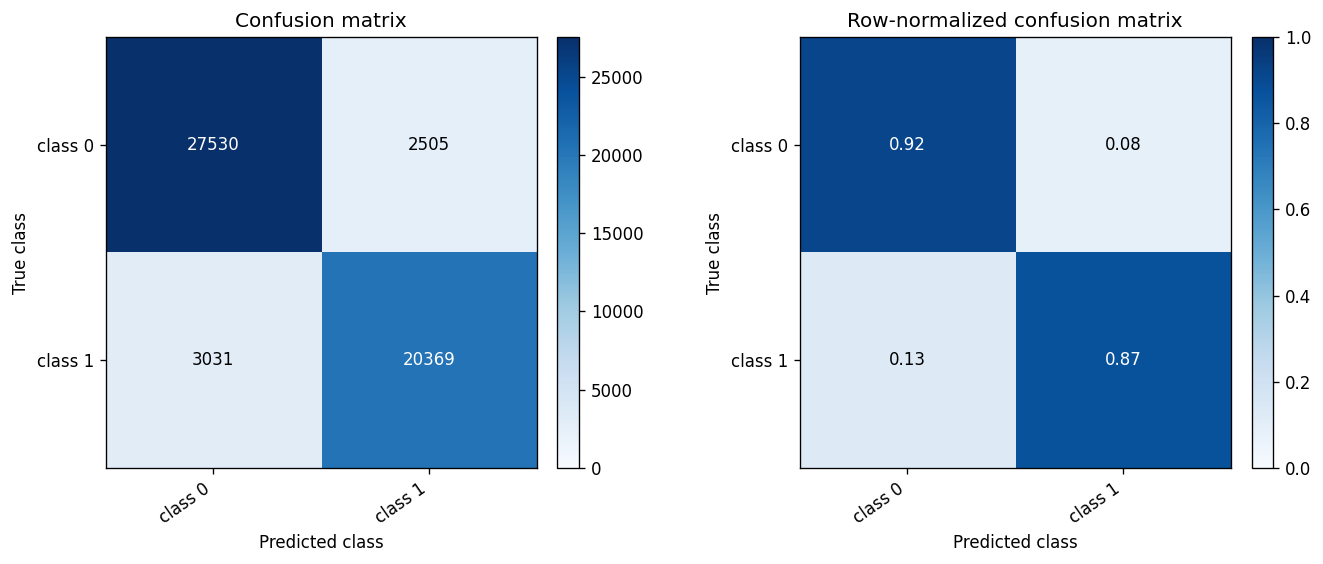

,class 0,class 1
class 0,27530,2505
class 1,3031,20369


In [2]:
def confusion_table(frame):
    work = frame[[true_class_col, pred_class_col]].dropna().copy()
    work[true_class_col] = work[true_class_col].astype(int)
    work[pred_class_col] = work[pred_class_col].astype(int)
    names = [class_label(label) for label in class_labels]
    table = pd.crosstab(work[true_class_col], work[pred_class_col]).reindex(
        index=class_labels, columns=class_labels, fill_value=0
    )
    table.index = names
    table.columns = names
    return table

cm_counts = confusion_table(df)
cm_norm = cm_counts.div(cm_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, table, title, fmt, vmax in [
    (axes[0], cm_counts, "Confusion matrix", "d", None),
    (axes[1], cm_norm, "Row-normalized confusion matrix", ".2f", 1),
]:
    im = ax.imshow(table.values, cmap="Blues", vmin=0, vmax=vmax)
    ax.set_xticks(np.arange(len(table.columns)), labels=table.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(table.index)), labels=table.index)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    threshold = np.nanmax(table.values) / 2 if table.values.size else 0
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            ax.text(j, i, format(value, fmt), ha="center", va="center", color="white" if value > threshold else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

cm_counts


### Classification Errors vs Energy

Counts and true-class-conditional error rates in the full test prediction sample.


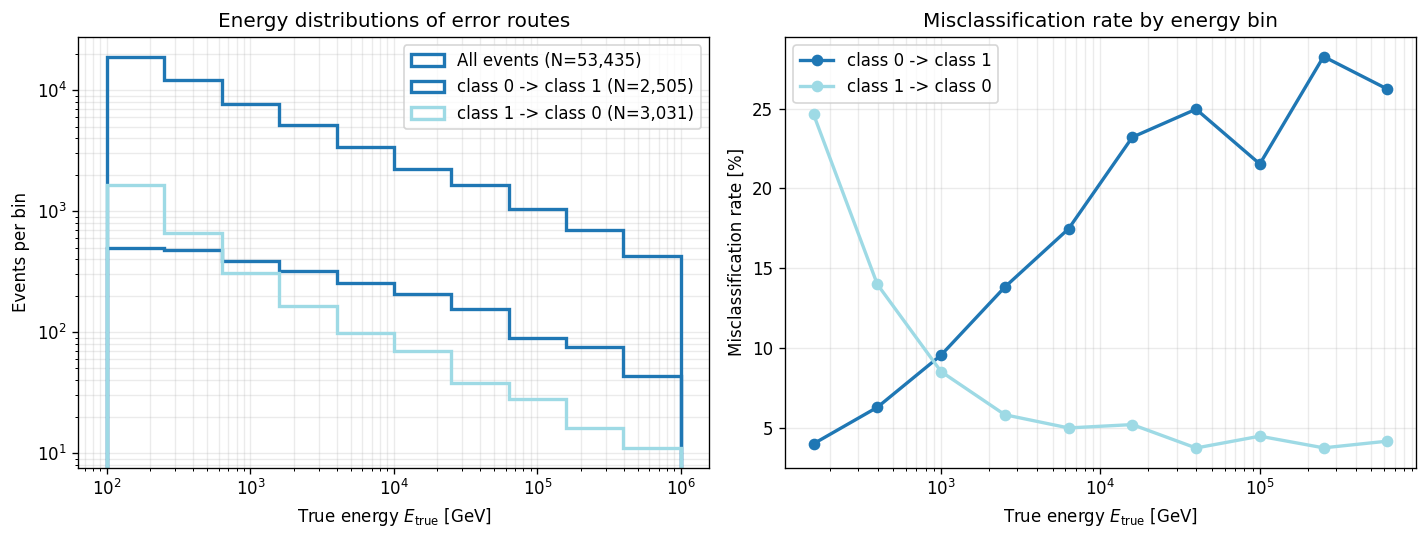

Misclassified events: 5,536 / 53,435 (10.360%)


,count,min_energy,median_energy,mean_energy,max_energy,median_percentile_in_full_sample
error_route,,,,,,
class 0 -> class 1,2505,100.932968,1200.490941,27082.334737,947248.572000,68.979134
class 1 -> class 0,3031,100.010445,222.512408,5845.971209,965068.135585,31.848040


In [3]:
classification_energy_df = df[[
    col for col in [
        "event_no", "pid", "is_CC", "category_3_contains_muon",
        "true_energy", "true_log10_energy", true_class_col, pred_class_col,
    ]
    if col in df.columns
]].dropna(subset=["true_energy", true_class_col, pred_class_col]).copy()
classification_energy_df = classification_energy_df[classification_energy_df["true_energy"] > 0]
classification_energy_df["is_misclassified"] = (
    classification_energy_df[true_class_col].astype(int)
    != classification_energy_df[pred_class_col].astype(int)
)
misclassified_df = classification_energy_df[classification_energy_df["is_misclassified"]].copy()
misclassified_df["energy_percentile_in_sample"] = (
    classification_energy_df["true_energy"].rank(pct=True).loc[misclassified_df.index] * 100
)
misclassified_df["true_class_name"] = misclassified_df[true_class_col].map(class_label)
misclassified_df["predicted_class_name"] = misclassified_df[pred_class_col].map(class_label)
misclassified_df["error_route"] = (
    misclassified_df["true_class_name"] + " -> " + misclassified_df["predicted_class_name"]
)

energy_edges = np.logspace(
    np.log10(classification_energy_df["true_energy"].min()),
    np.log10(classification_energy_df["true_energy"].max()),
    11,
)
energy_centers = np.sqrt(energy_edges[:-1] * energy_edges[1:])
error_route_groups = list(misclassified_df.groupby("error_route", sort=True))
error_colors = plt.get_cmap("tab20")(
    np.linspace(0, 1, max(len(error_route_groups), 1))
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].hist(
    classification_energy_df["true_energy"],
    bins=energy_edges,
    histtype="step",
    linewidth=2,
    label=f"All events (N={len(classification_energy_df):,})",
)
for (route, group), color in zip(error_route_groups, error_colors):
    axes[0].hist(
        group["true_energy"],
        bins=energy_edges,
        histtype="step",
        linewidth=2,
        color=color,
        label=f"{route} (N={len(group):,})",
    )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"True energy $E_\mathrm{true}$ [GeV]")
axes[0].set_ylabel("Events per bin")
axes[0].set_title("Energy distributions of error routes")
axes[0].grid(True, alpha=0.25, which="both")
axes[0].legend()

for (route, group), color in zip(error_route_groups, error_colors):
    true_label = int(group[true_class_col].iloc[0])
    denominator = classification_energy_df[
        classification_energy_df[true_class_col].astype(int) == true_label
    ]
    total_counts, _ = np.histogram(denominator["true_energy"], bins=energy_edges)
    wrong_counts, _ = np.histogram(group["true_energy"], bins=energy_edges)
    route_rate = np.divide(
        wrong_counts,
        total_counts,
        out=np.full(wrong_counts.shape, np.nan, dtype=float),
        where=total_counts > 0,
    )
    axes[1].plot(
        energy_centers,
        100 * route_rate,
        marker="o",
        linewidth=2,
        color=color,
        label=route,
    )
axes[1].set_xscale("log")
axes[1].set_xlabel(r"True energy $E_\mathrm{true}$ [GeV]")
axes[1].set_ylabel("Misclassification rate [%]")
axes[1].set_title("Misclassification rate by energy bin")
axes[1].grid(True, alpha=0.25, which="both")
axes[1].legend()
fig.tight_layout()
plt.show()

print(
    f"Misclassified events: {len(misclassified_df):,} / "
    f"{len(classification_energy_df):,} "
    f"({100 * len(misclassified_df) / len(classification_energy_df):.3f}%)"
)
error_energy_summary = misclassified_df.groupby("error_route")["true_energy"].agg(
    count="size",
    min_energy="min",
    median_energy="median",
    mean_energy="mean",
    max_energy="max",
)
error_energy_summary["median_percentile_in_full_sample"] = misclassified_df.groupby(
    "error_route"
)["energy_percentile_in_sample"].median()
error_energy_summary


Result:  The misclassification pattern is strongly energy-dependent: low-energy muon-CC events are more likely to be misclassified as non-muon-CC, whereas the probability of misclassifying non-muon-CC events as muon-CC increases with energy.

### Contains-Muon Composition of Misclassified Events

Counts and within-error-route percentages for the `category_3_contains_muon` truth label.


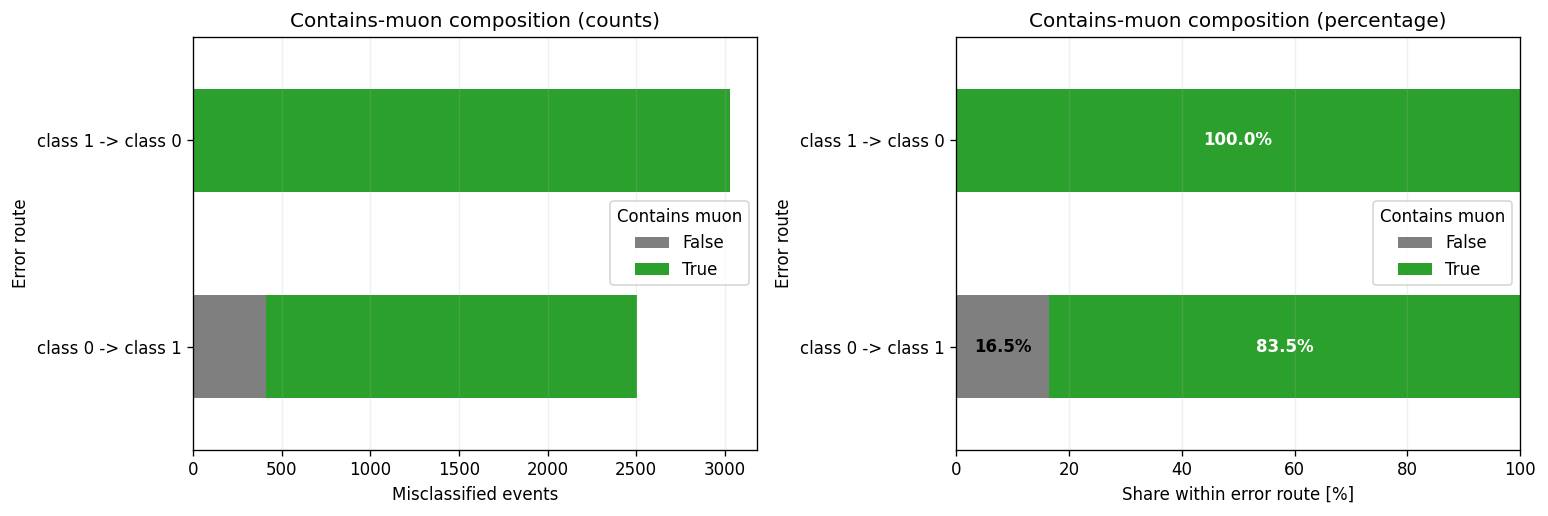

count          percent            
contains_muon      False  True      False        True
error_route                                          
class 0 -> class 1   413  2092  16.487026   83.512974
class 1 -> class 0     0  3031   0.000000  100.000000

In [4]:
contains_muon_col = "category_3_contains_muon"

if contains_muon_col not in misclassified_df.columns:
    print(f"{contains_muon_col} is not available in inference predictions.")
    contains_muon_summary = pd.DataFrame()
else:
    contains_muon_df = misclassified_df.dropna(
        subset=["error_route", contains_muon_col]
    ).copy()
    contains_muon_df["contains_muon"] = (
        contains_muon_df[contains_muon_col]
        .astype(int)
        .map({0: "False", 1: "True"})
    )

    contains_muon_counts = pd.crosstab(
        contains_muon_df["error_route"], contains_muon_df["contains_muon"]
    ).reindex(columns=["False", "True"], fill_value=0)
    contains_muon_percent = (
        contains_muon_counts
        .div(contains_muon_counts.sum(axis=1).replace(0, np.nan), axis=0)
        .mul(100)
        .fillna(0)
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, max(4.4, 0.7 * len(contains_muon_counts))))
    composition_colors = ["tab:gray", "tab:green"]
    contains_muon_counts.plot(
        kind="barh", stacked=True, color=composition_colors, ax=axes[0]
    )
    axes[0].set_xlabel("Misclassified events")
    axes[0].set_ylabel("Error route")
    axes[0].set_title("Contains-muon composition (counts)")
    axes[0].grid(True, alpha=0.2, axis="x")

    contains_muon_percent.plot(
        kind="barh", stacked=True, color=composition_colors, ax=axes[1]
    )
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel("Share within error route [%]")
    axes[1].set_ylabel("Error route")
    axes[1].set_title("Contains-muon composition (percentage)")
    axes[1].grid(True, alpha=0.2, axis="x")

    for row, (_, values) in enumerate(contains_muon_percent.iterrows()):
        left = 0.0
        for value in values:
            if value >= 3:
                axes[1].text(
                    left + value / 2,
                    row,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    color="white" if value >= 20 else "black",
                    fontweight="bold",
                )
            left += value

    for ax in axes:
        ax.legend(title="Contains muon")
    fig.tight_layout()
    plt.show()

    contains_muon_summary = pd.concat(
        {"count": contains_muon_counts, "percent": contains_muon_percent},
        axis=1,
    )

contains_muon_summary


Result: Among non-muon-CC events misclassified as muon-CC (class 0 → class 1), 83.5% contain a muon in Postprop, while only 16.5% do not. This suggests that the presence of a muon in Postprop strongly influences the classifier toward the muon-CC class, even when the event is not truly a muon-CC interaction.


## Section 2 - Energy


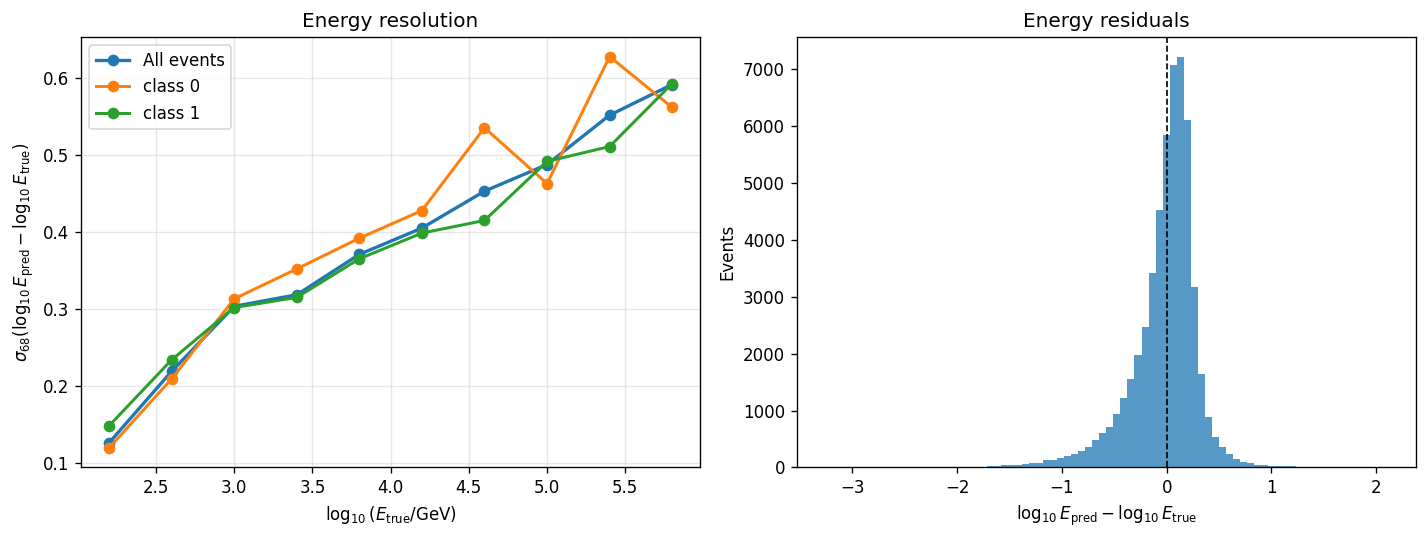

,count,median,mean,sigma68
0,53435,0.039639,-0.021218,0.241368


In [5]:
energy_needed = ["true_energy", "true_log10_energy", "pred_energy", "pred_log10_energy", true_class_col, analysis_group_col, pid_interaction_exact_col, confusion_route_col]
energy_df = df[[col for col in energy_needed if col in df.columns]].dropna().copy()
energy_df = energy_df[(energy_df["true_energy"] > 0) & (energy_df["pred_energy"] > 0)]
energy_df["energy_residual_log10"] = energy_df["pred_log10_energy"] - energy_df["true_log10_energy"]
bins = np.linspace(energy_df["true_log10_energy"].min(), energy_df["true_log10_energy"].max(), 11)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(energy_df, "true_log10_energy", "energy_residual_log10", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in energy_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "energy_residual_log10", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"$\sigma_{68}(\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true})$")
axes[0].set_title("Energy resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(energy_df["energy_residual_log10"], bins=80, histtype="stepfilled", alpha=0.75)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$")
axes[1].set_ylabel("Events")
axes[1].set_title("Energy residuals")
fig.tight_layout()
plt.show()

pd.DataFrame({
    "count": [len(energy_df)],
    "median": [energy_df["energy_residual_log10"].median()],
    "mean": [energy_df["energy_residual_log10"].mean()],
    "sigma68": [sigma68(energy_df["energy_residual_log10"])],
})


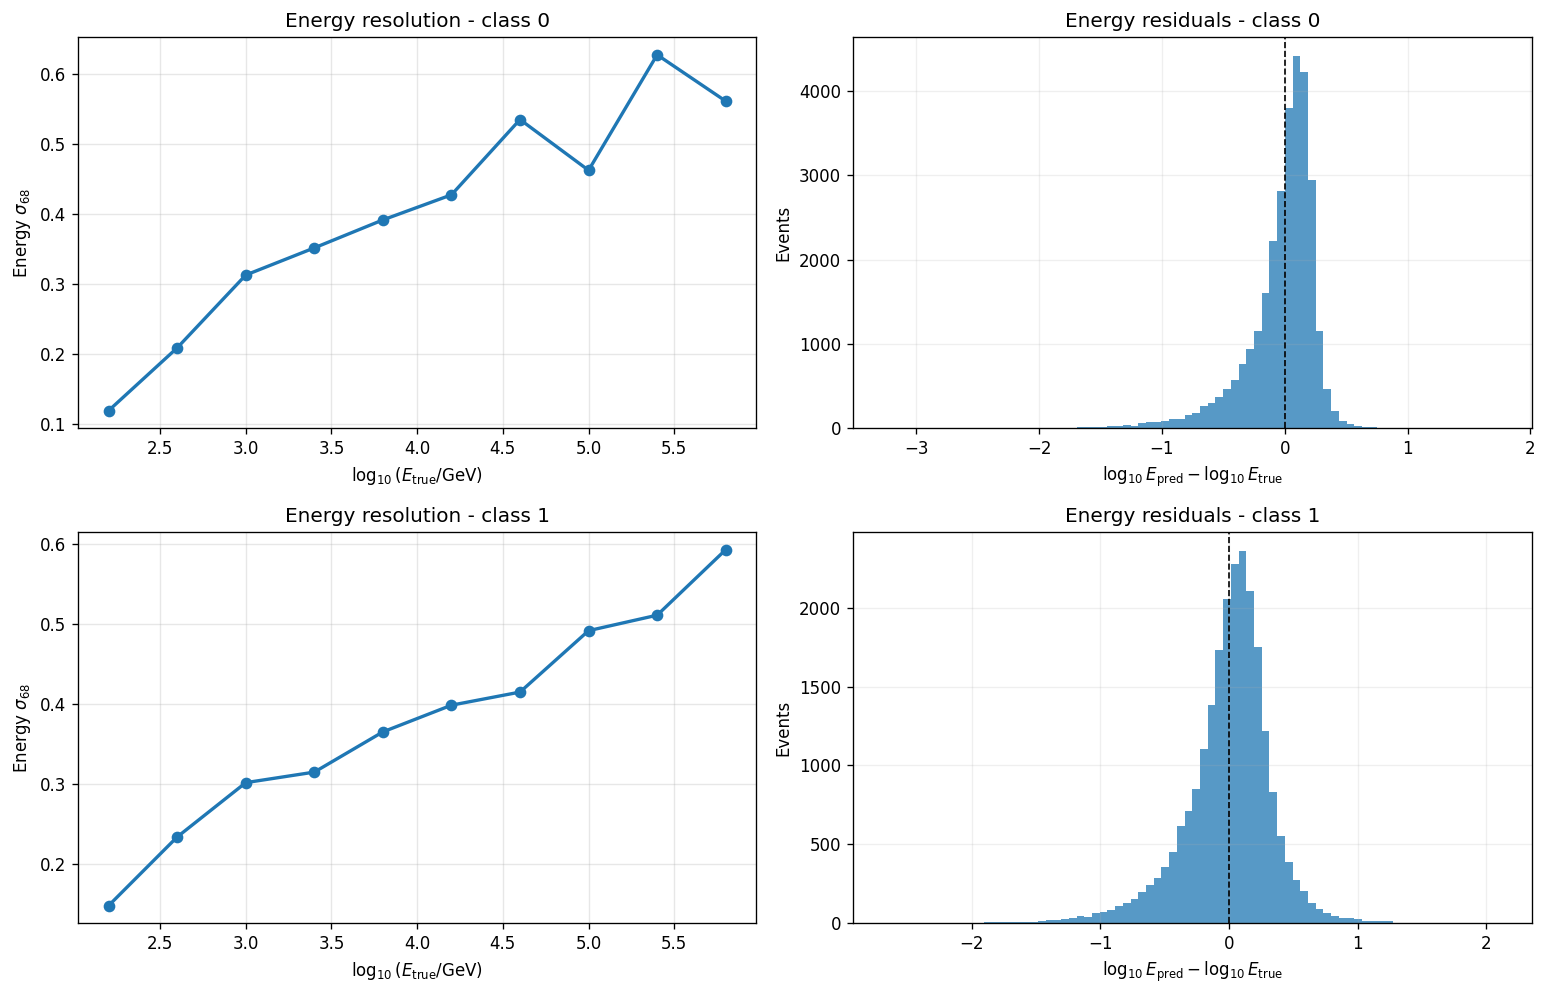

In [6]:
plot_resolution_and_residual_groups(
    energy_df,
    class_grouped_frames(energy_df),
    residual_col="energy_residual_log10",
    y_label=r"Energy $\sigma_{68}$",
    residual_xlabel=r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$",
    title_prefix="Energy",
    color="tab:blue",
)


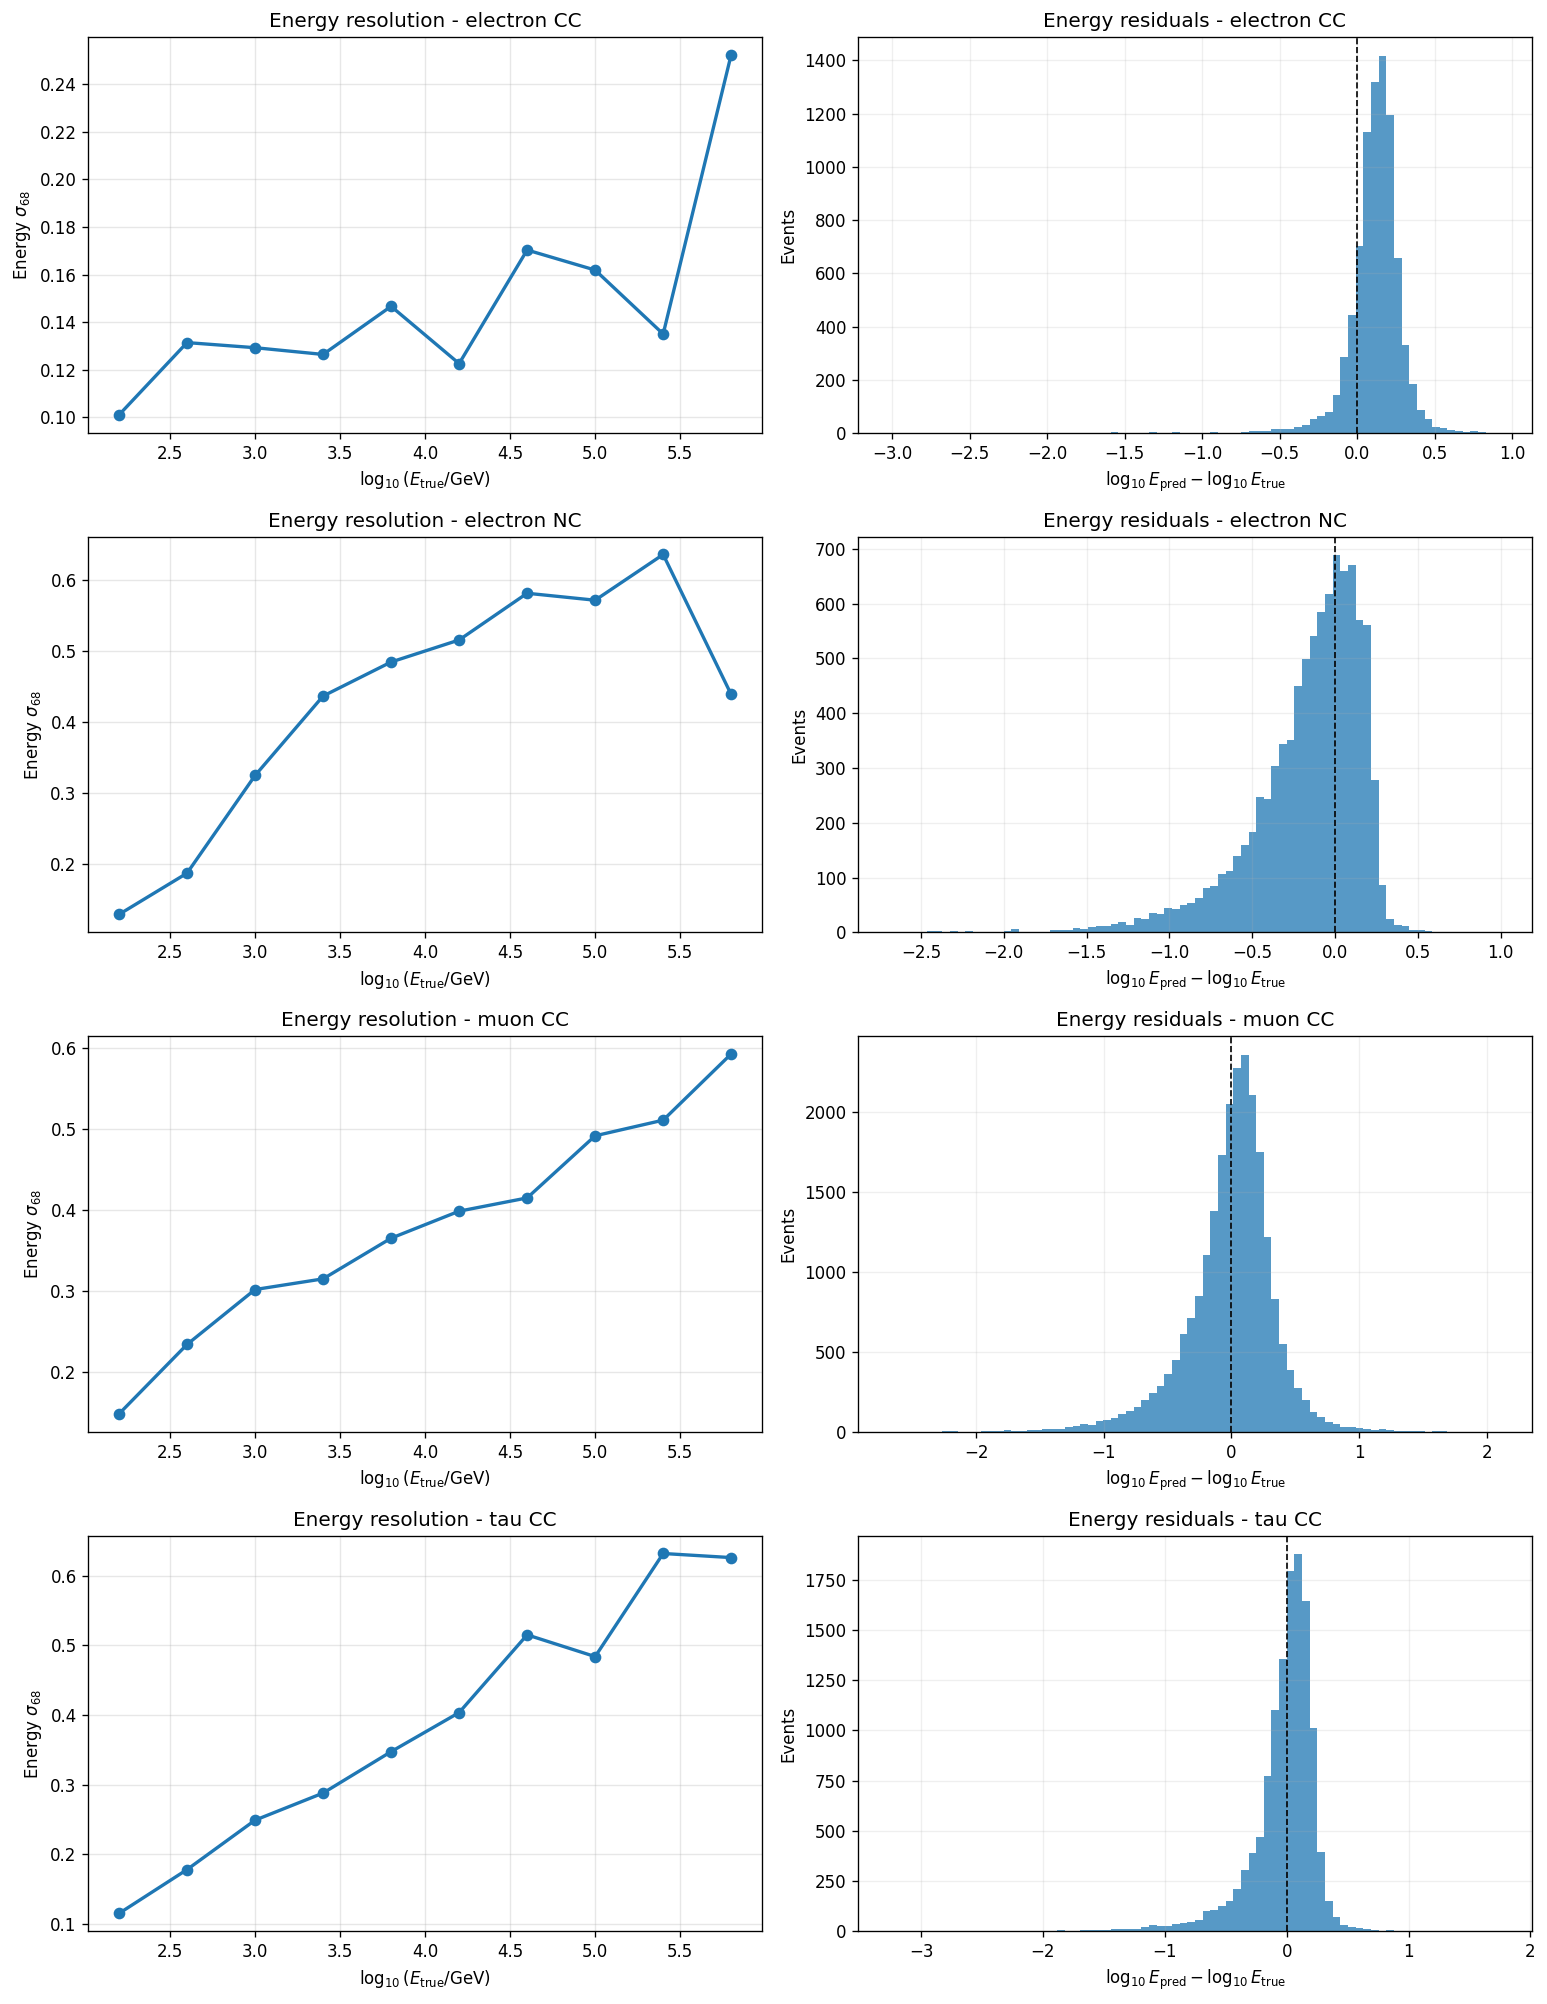

In [7]:
plot_resolution_and_residual_groups(
    energy_df,
    pid_interaction_grouped_frames(energy_df),
    residual_col="energy_residual_log10",
    y_label=r"Energy $\sigma_{68}$",
    residual_xlabel=r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$",
    title_prefix="Energy",
    color="tab:blue",
)


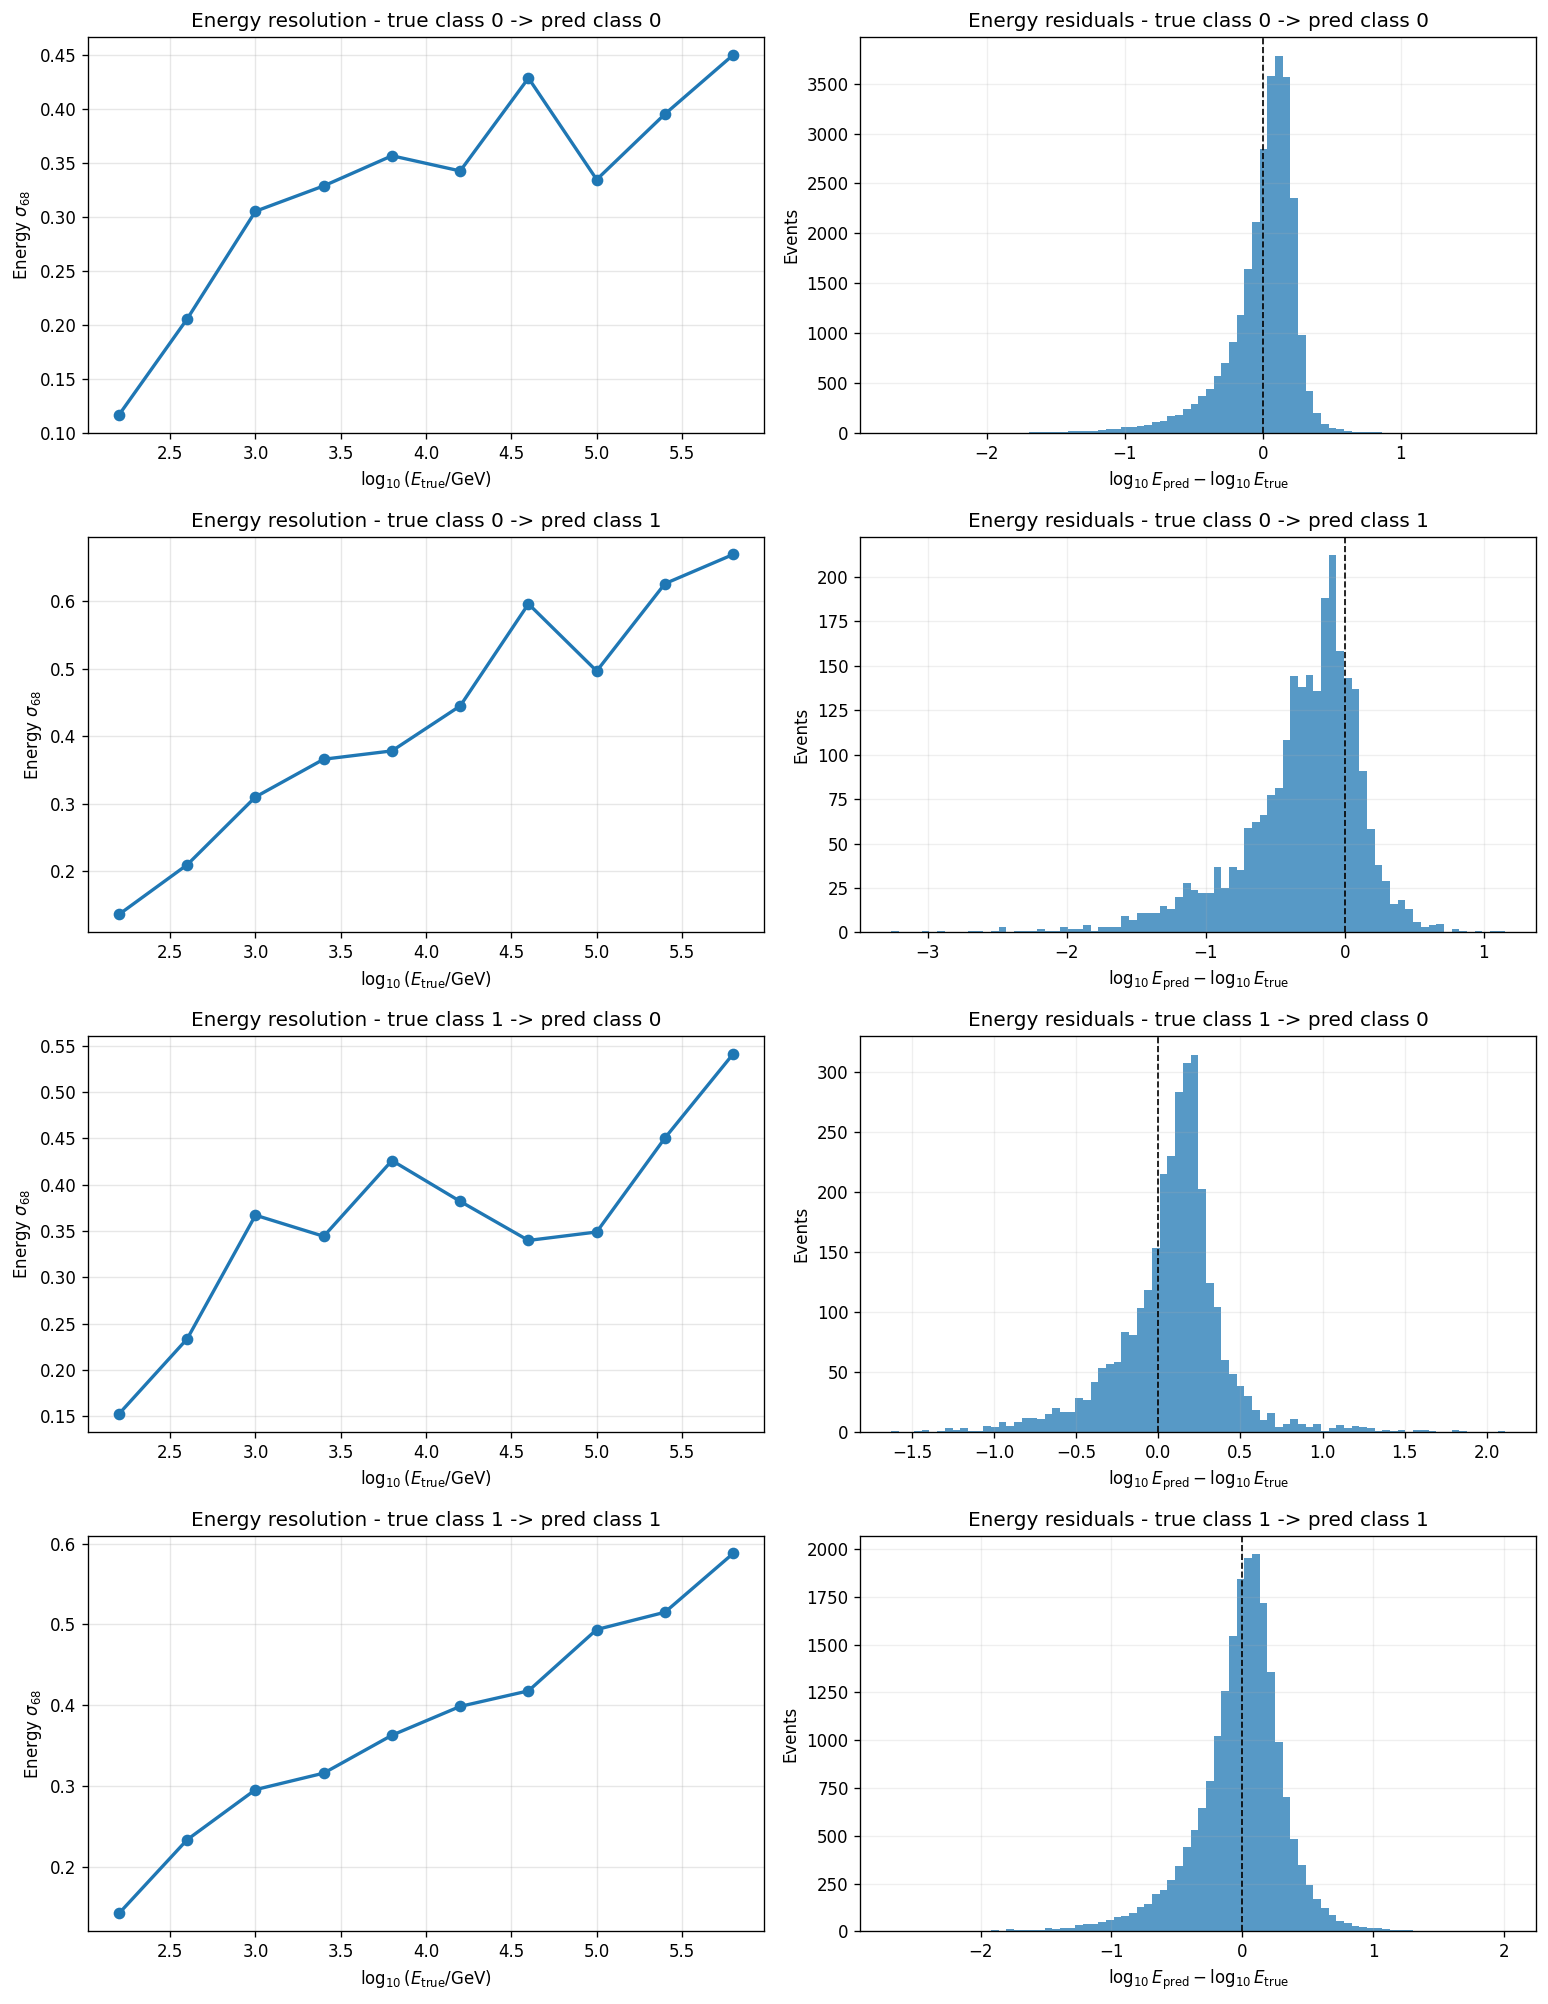

In [8]:
plot_resolution_and_residual_groups(
    energy_df,
    confusion_route_grouped_frames(energy_df),
    residual_col="energy_residual_log10",
    y_label=r"Energy $\sigma_{68}$",
    residual_xlabel=r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$",
    title_prefix="Energy",
    color="tab:blue",
)


## Section 3 - Zenith


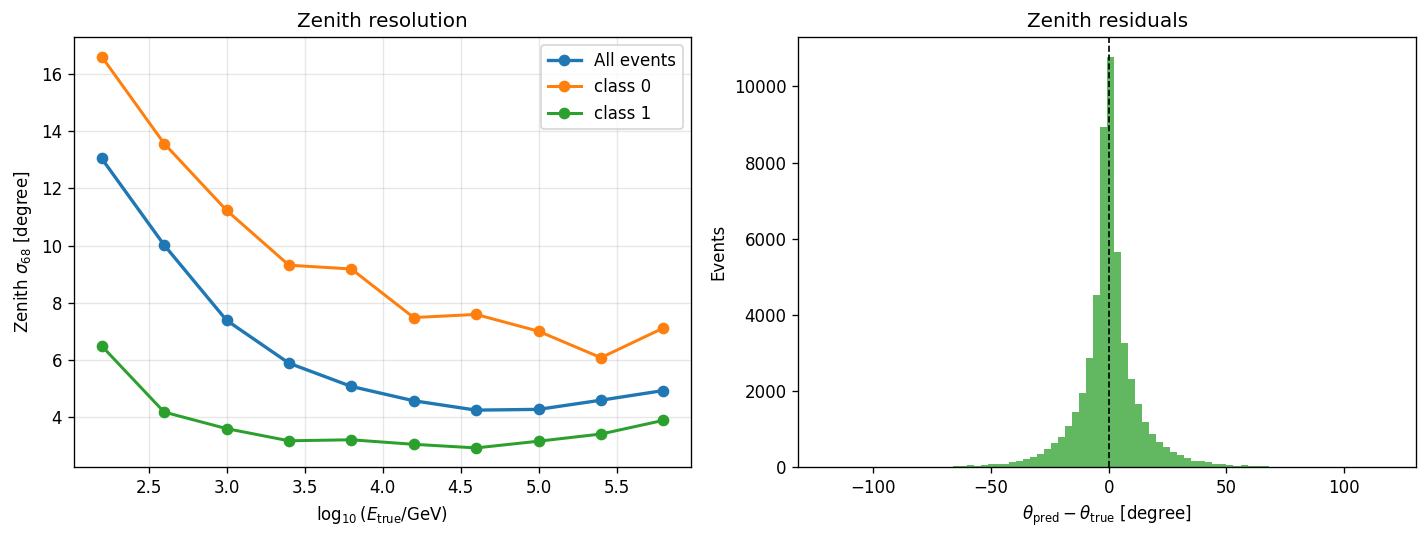

In [9]:
zenith_residual_col = "zenith_residual_zenith_degree" if "zenith_residual_zenith_degree" in df.columns else "residual_zenith_degree"
zenith_cols = ["true_log10_energy", zenith_residual_col, true_class_col, analysis_group_col, pid_interaction_exact_col, confusion_route_col]
zenith_df = df[[col for col in zenith_cols if col in df.columns]].dropna().copy()
zenith_df = zenith_df.rename(columns={zenith_residual_col: "zenith_residual_degree"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(zenith_df, "true_log10_energy", "zenith_residual_degree", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in zenith_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "zenith_residual_degree", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"Zenith $\sigma_{68}$ [degree]")
axes[0].set_title("Zenith resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(zenith_df["zenith_residual_degree"], bins=80, histtype="stepfilled", alpha=0.75, color="tab:green")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]")
axes[1].set_ylabel("Events")
axes[1].set_title("Zenith residuals")
fig.tight_layout()
plt.show()


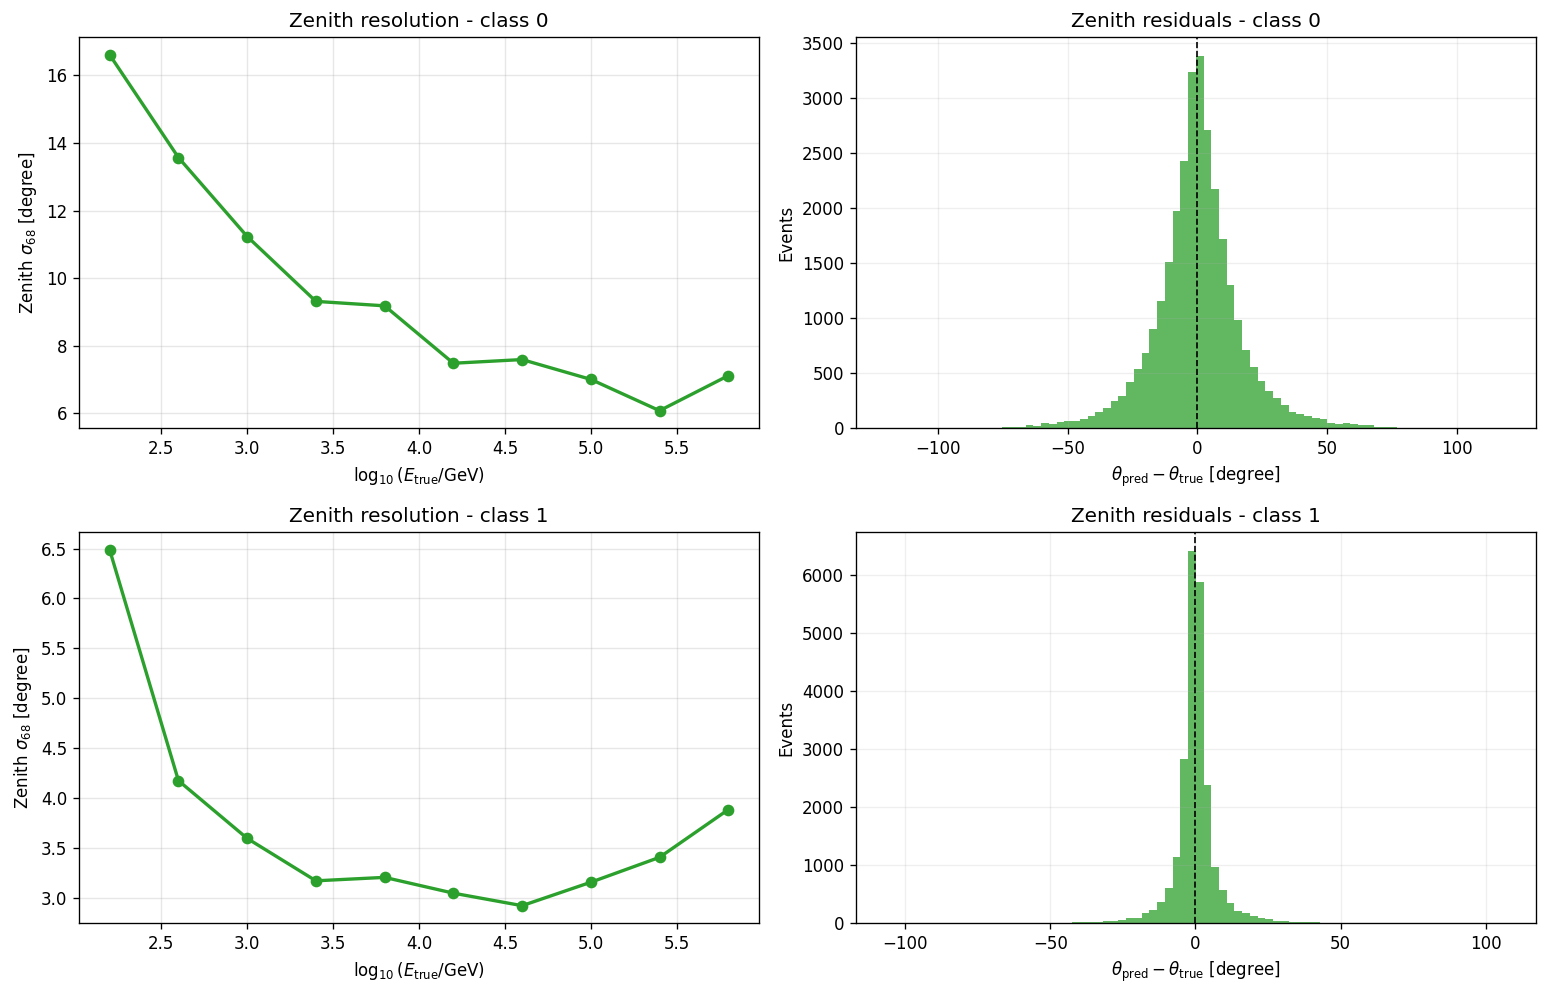

In [10]:
plot_resolution_and_residual_groups(
    zenith_df,
    class_grouped_frames(zenith_df),
    residual_col="zenith_residual_degree",
    y_label=r"Zenith $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]",
    title_prefix="Zenith",
    color="tab:green",
)


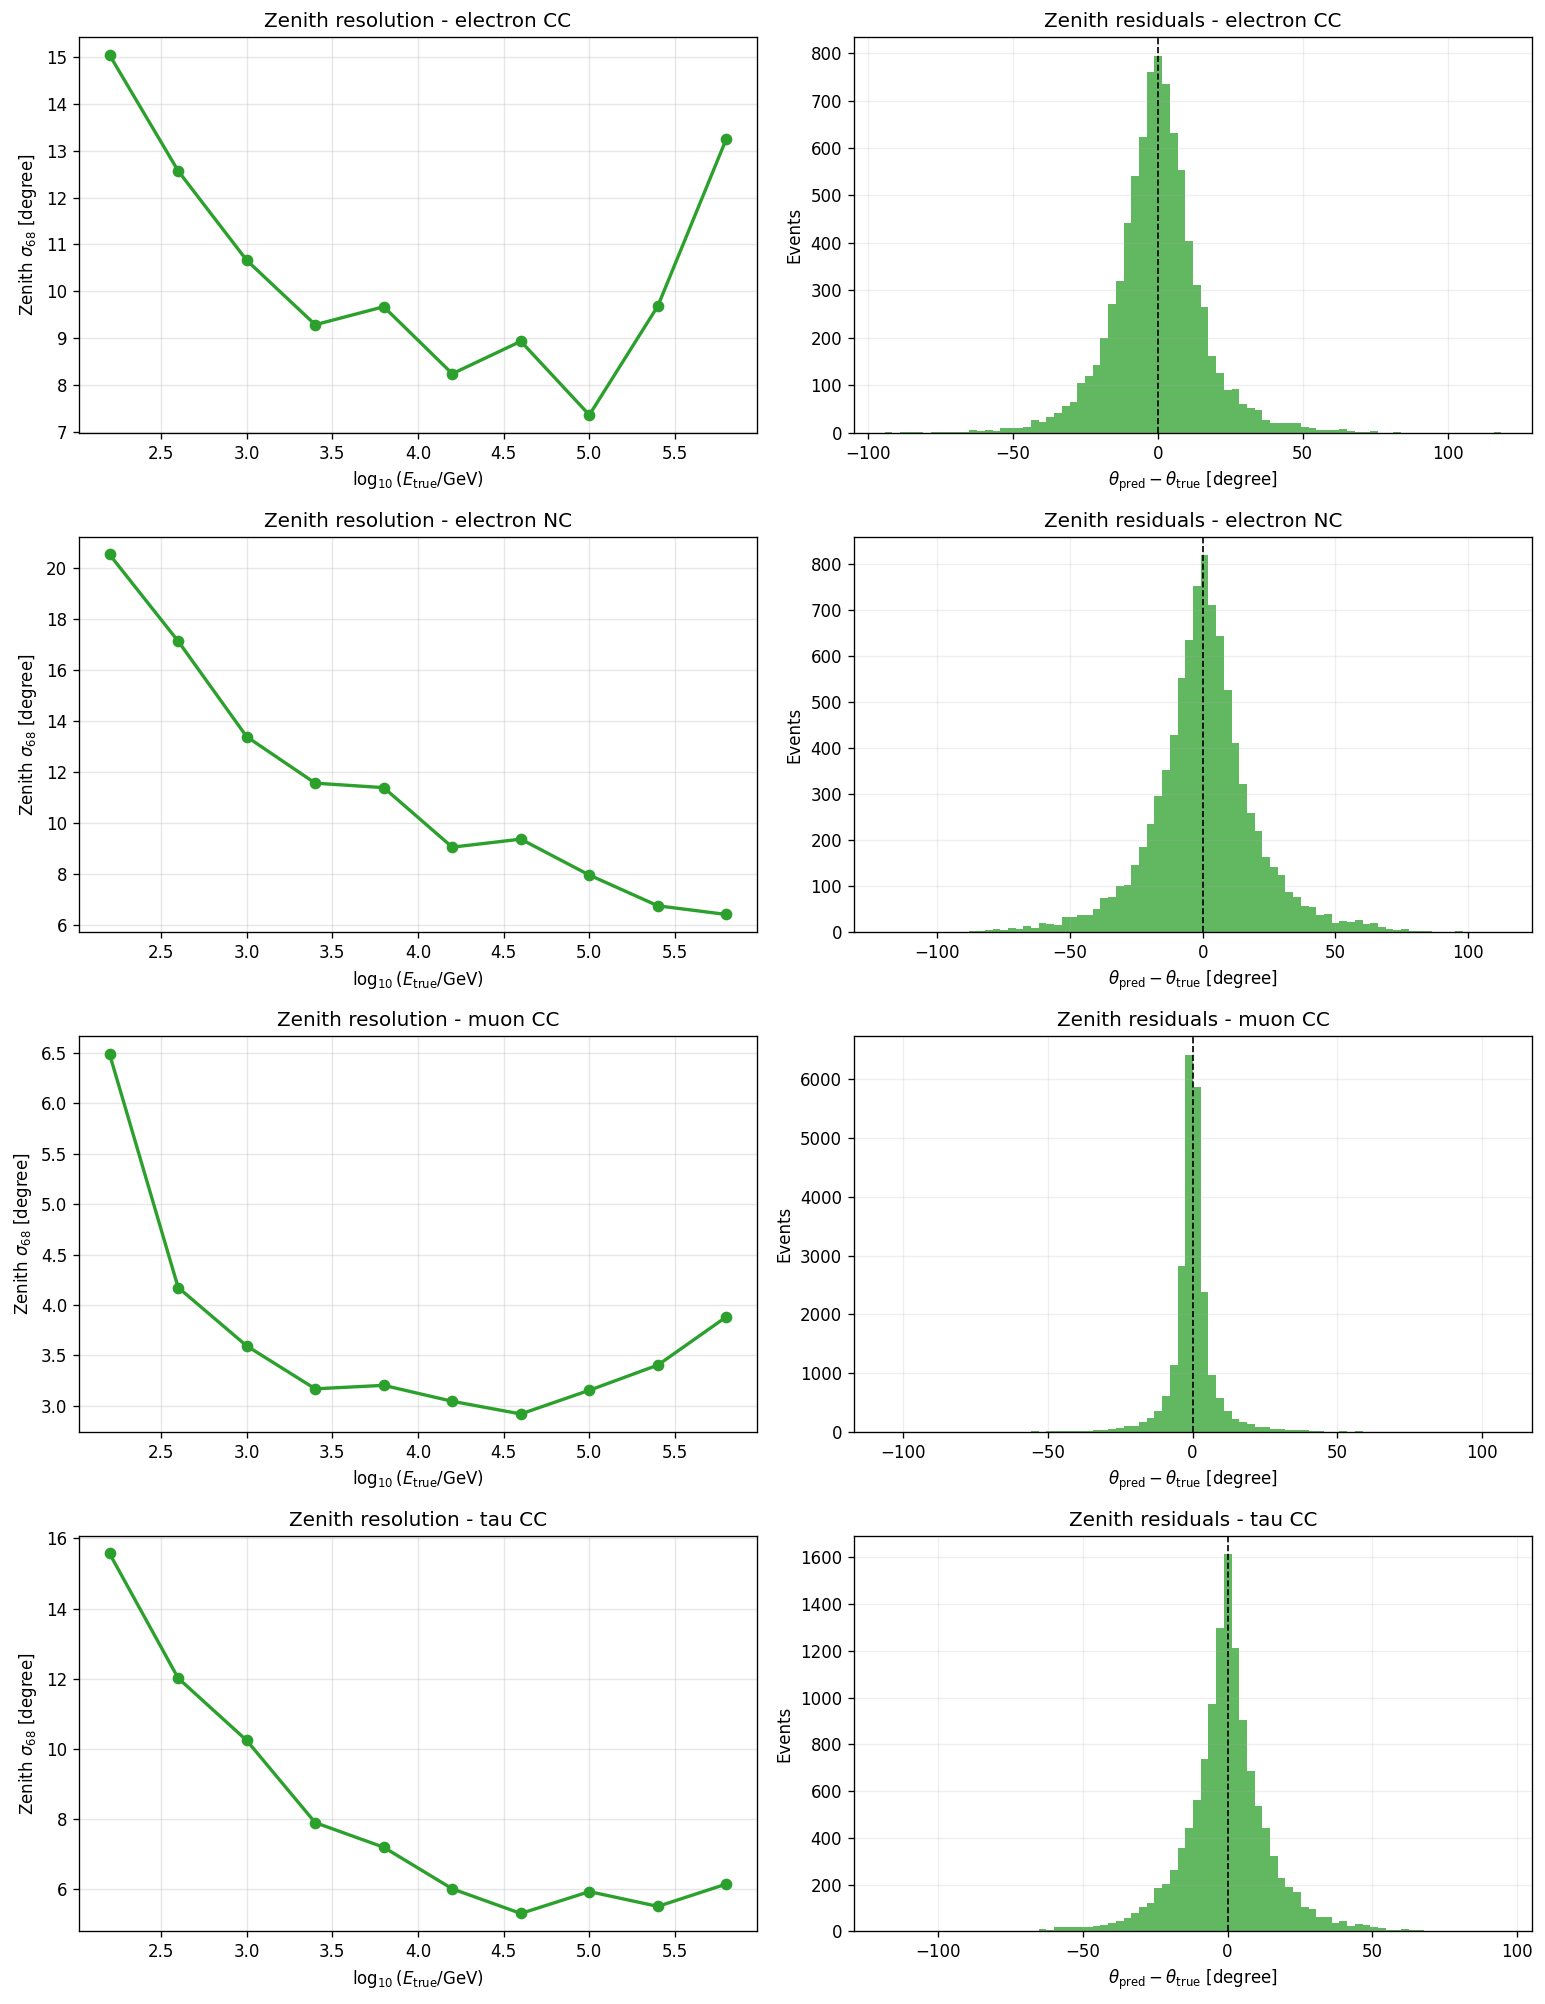

In [11]:
plot_resolution_and_residual_groups(
    zenith_df,
    pid_interaction_grouped_frames(zenith_df),
    residual_col="zenith_residual_degree",
    y_label=r"Zenith $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]",
    title_prefix="Zenith",
    color="tab:green",
)


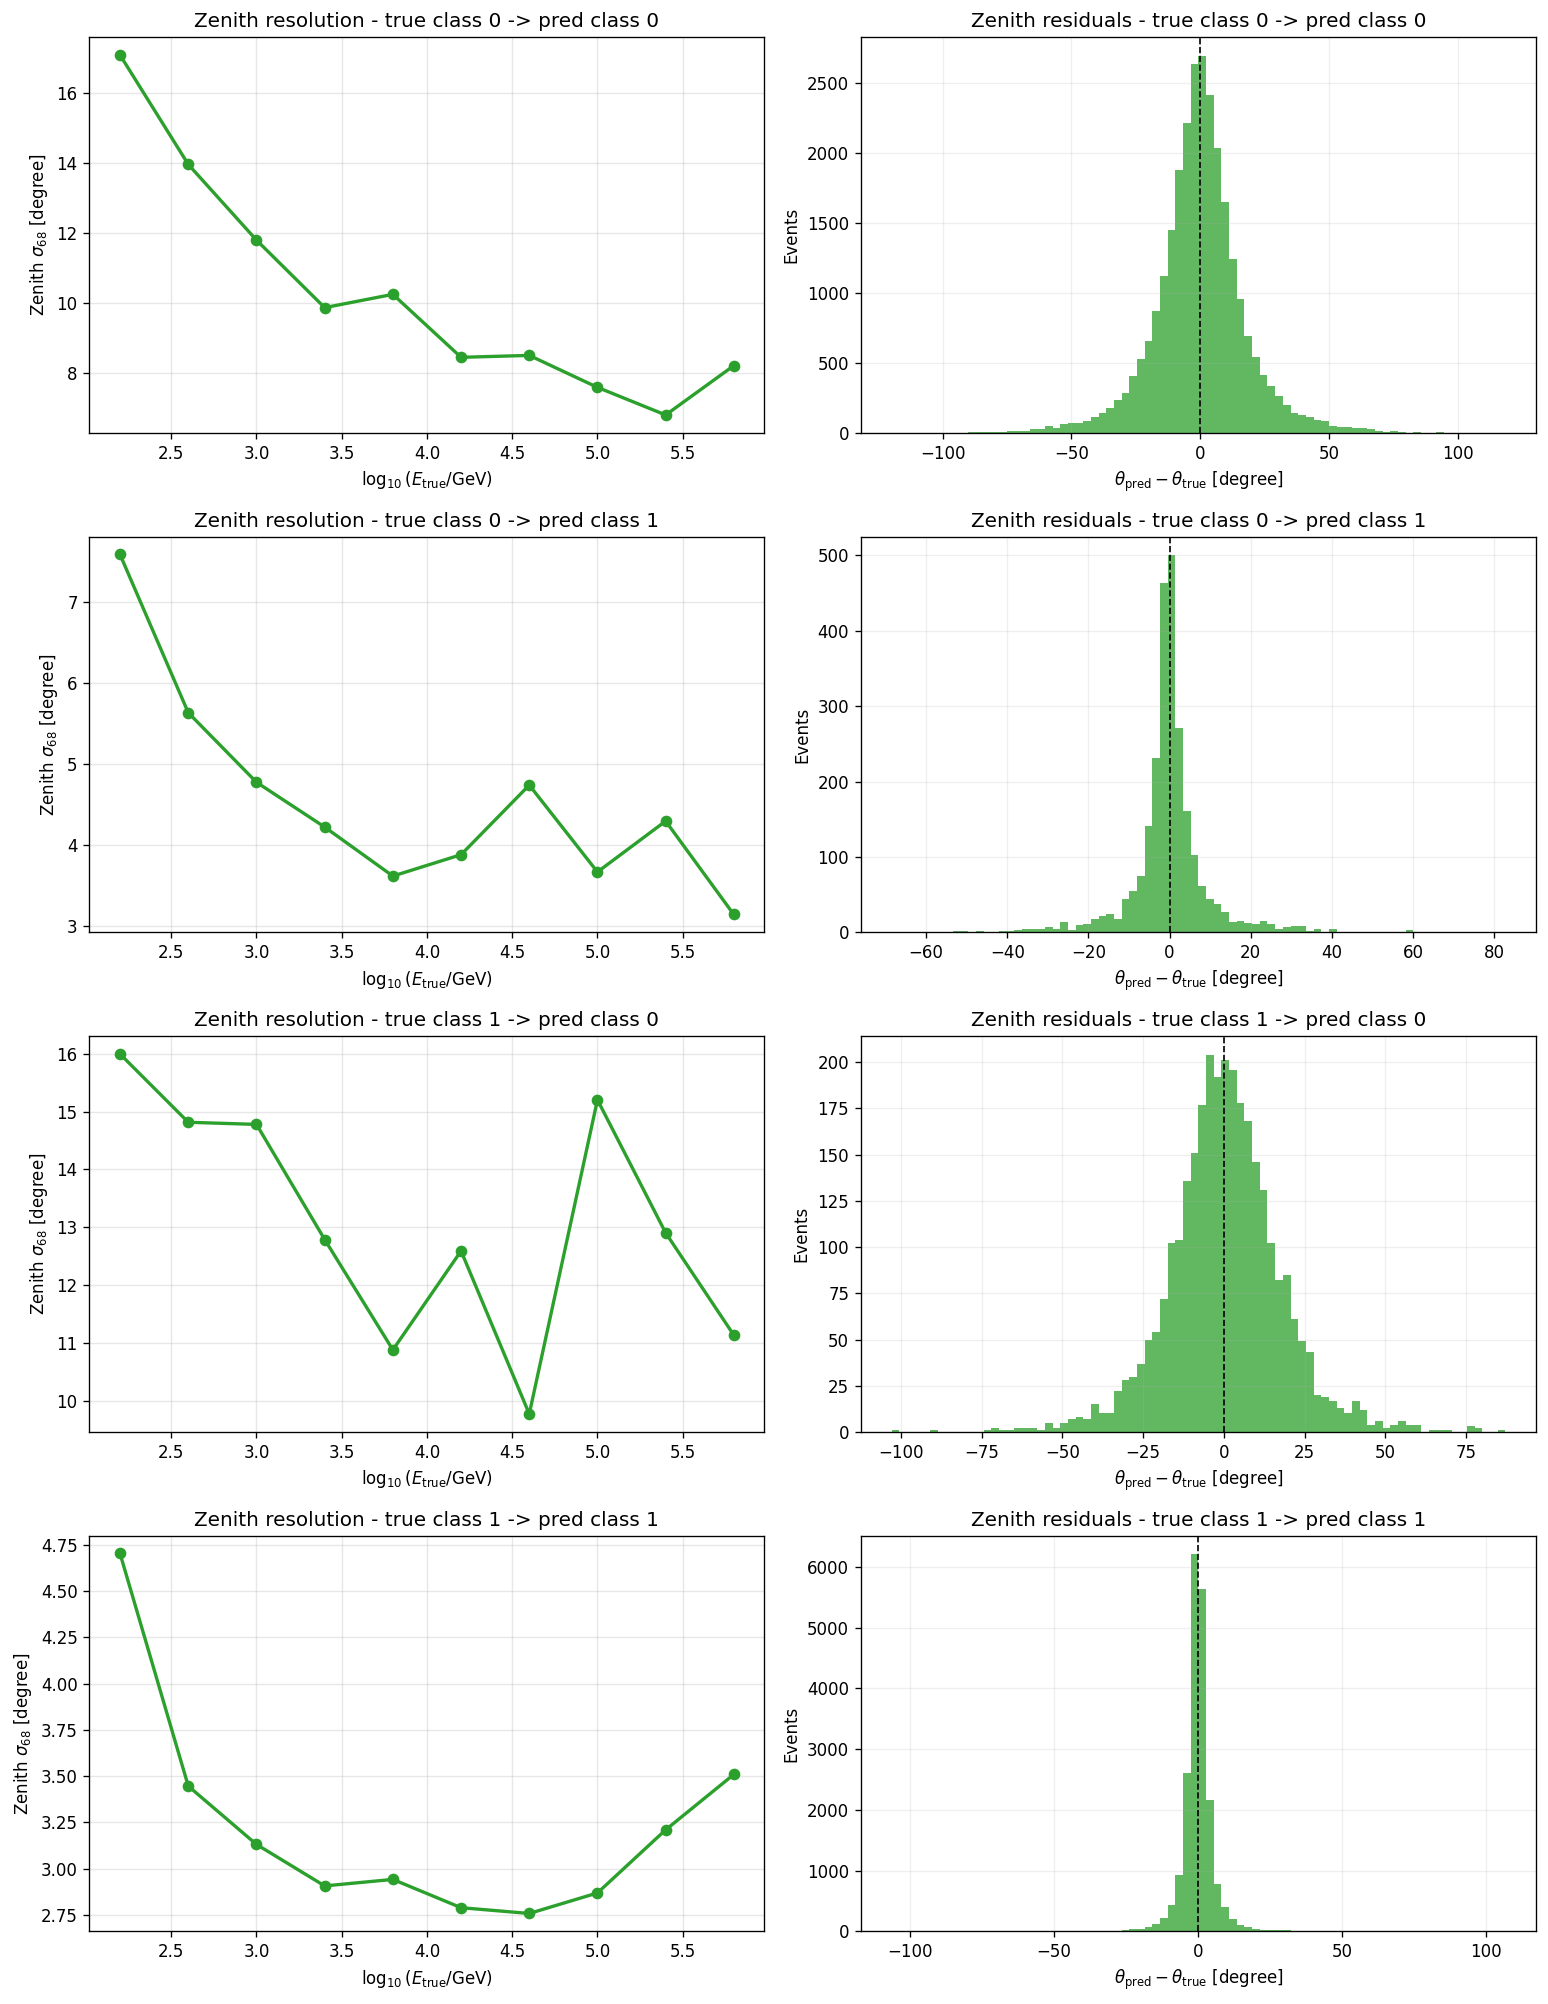

In [12]:
plot_resolution_and_residual_groups(
    zenith_df,
    confusion_route_grouped_frames(zenith_df),
    residual_col="zenith_residual_degree",
    y_label=r"Zenith $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]",
    title_prefix="Zenith",
    color="tab:green",
)


## Section 4 - Azimuth


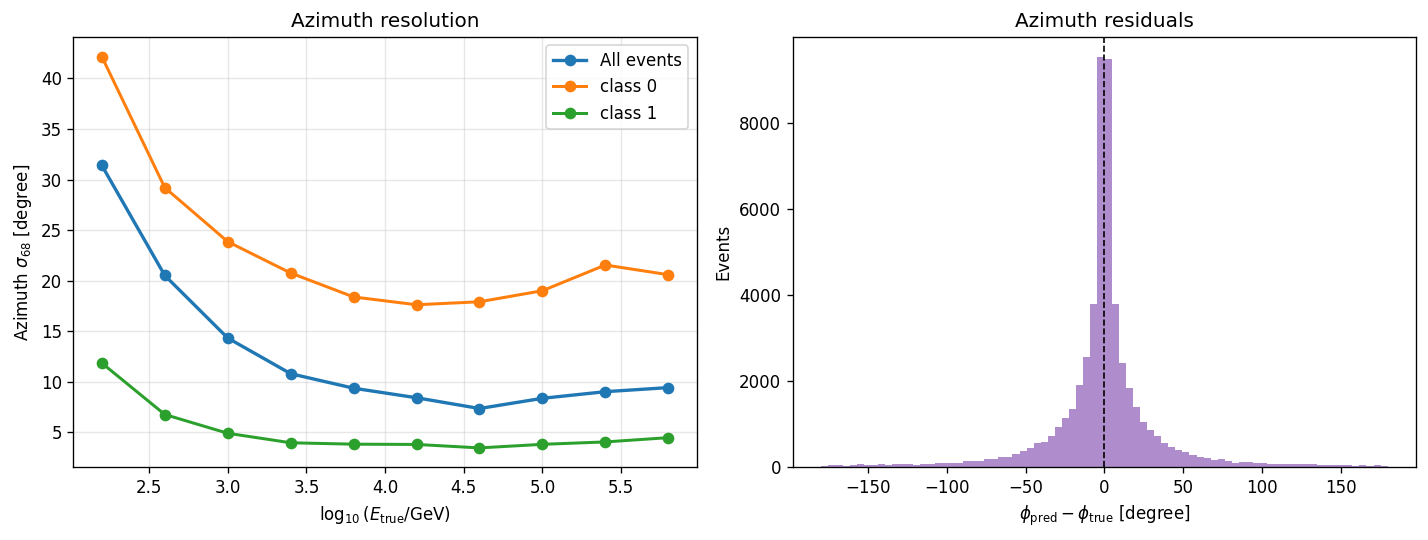

In [13]:
azimuth_residual_col = "azimuth_residual_azimuth_degree" if "azimuth_residual_azimuth_degree" in df.columns else "residual_azimuth_degree"
azimuth_cols = ["true_log10_energy", azimuth_residual_col, true_class_col, analysis_group_col, pid_interaction_exact_col, confusion_route_col]
azimuth_df = df[[col for col in azimuth_cols if col in df.columns]].dropna().copy()
azimuth_df = azimuth_df.rename(columns={azimuth_residual_col: "azimuth_residual_degree"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(azimuth_df, "true_log10_energy", "azimuth_residual_degree", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in azimuth_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "azimuth_residual_degree", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"Azimuth $\sigma_{68}$ [degree]")
axes[0].set_title("Azimuth resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(azimuth_df["azimuth_residual_degree"], bins=80, histtype="stepfilled", alpha=0.75, color="tab:purple")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]")
axes[1].set_ylabel("Events")
axes[1].set_title("Azimuth residuals")
fig.tight_layout()
plt.show()


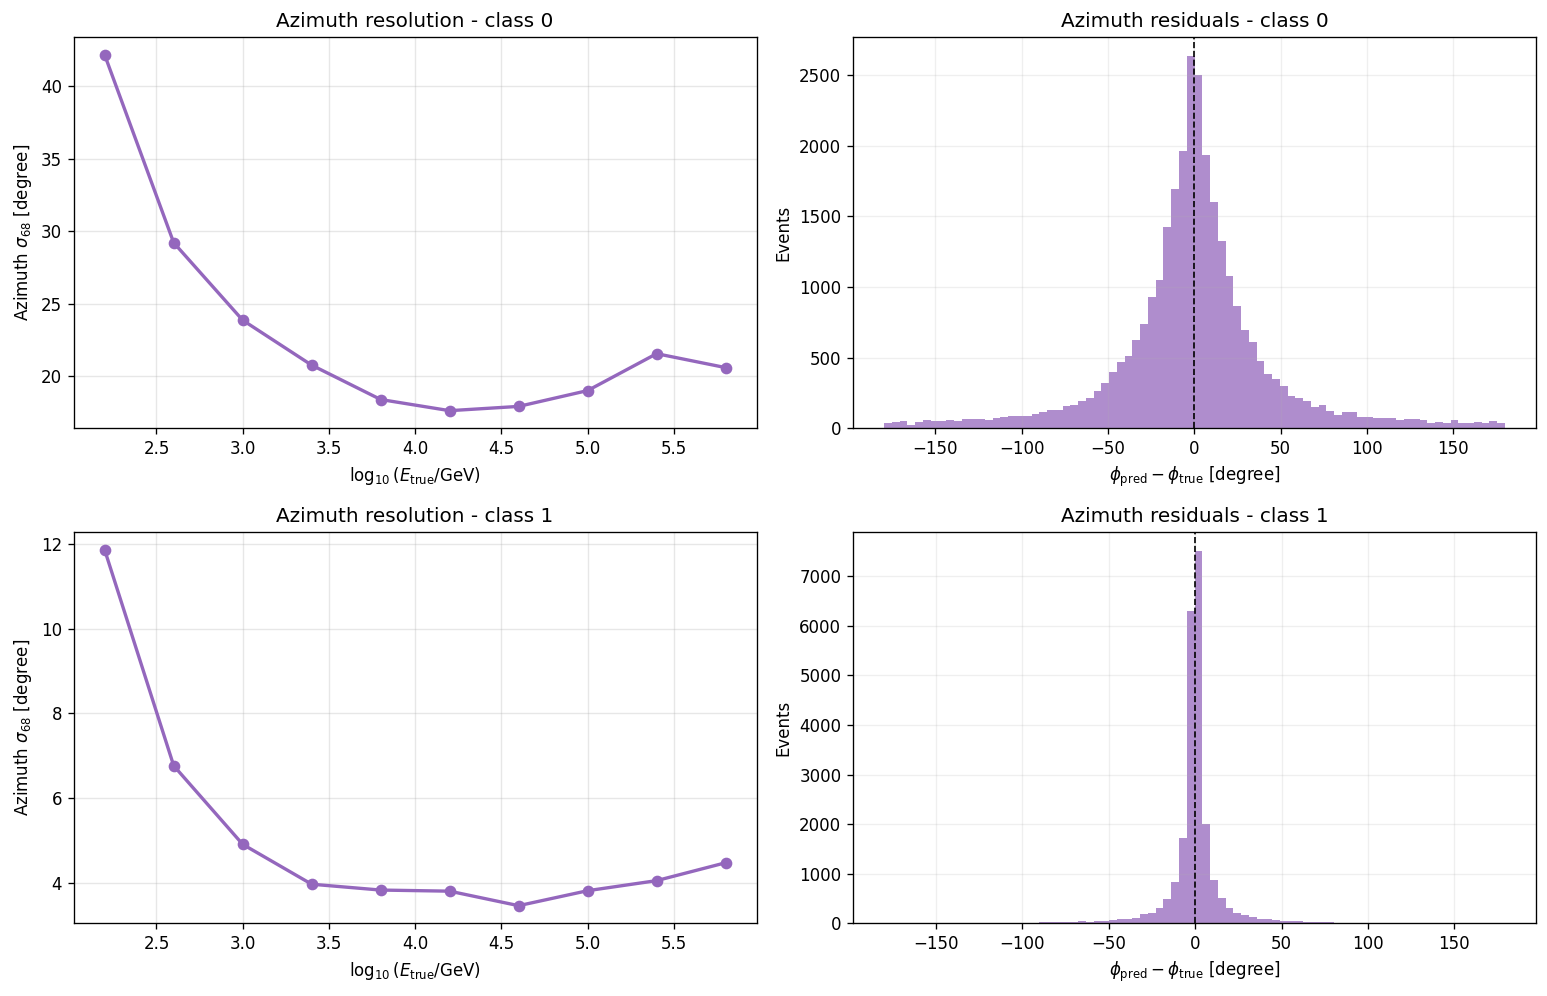

In [14]:
plot_resolution_and_residual_groups(
    azimuth_df,
    class_grouped_frames(azimuth_df),
    residual_col="azimuth_residual_degree",
    y_label=r"Azimuth $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]",
    title_prefix="Azimuth",
    color="tab:purple",
)


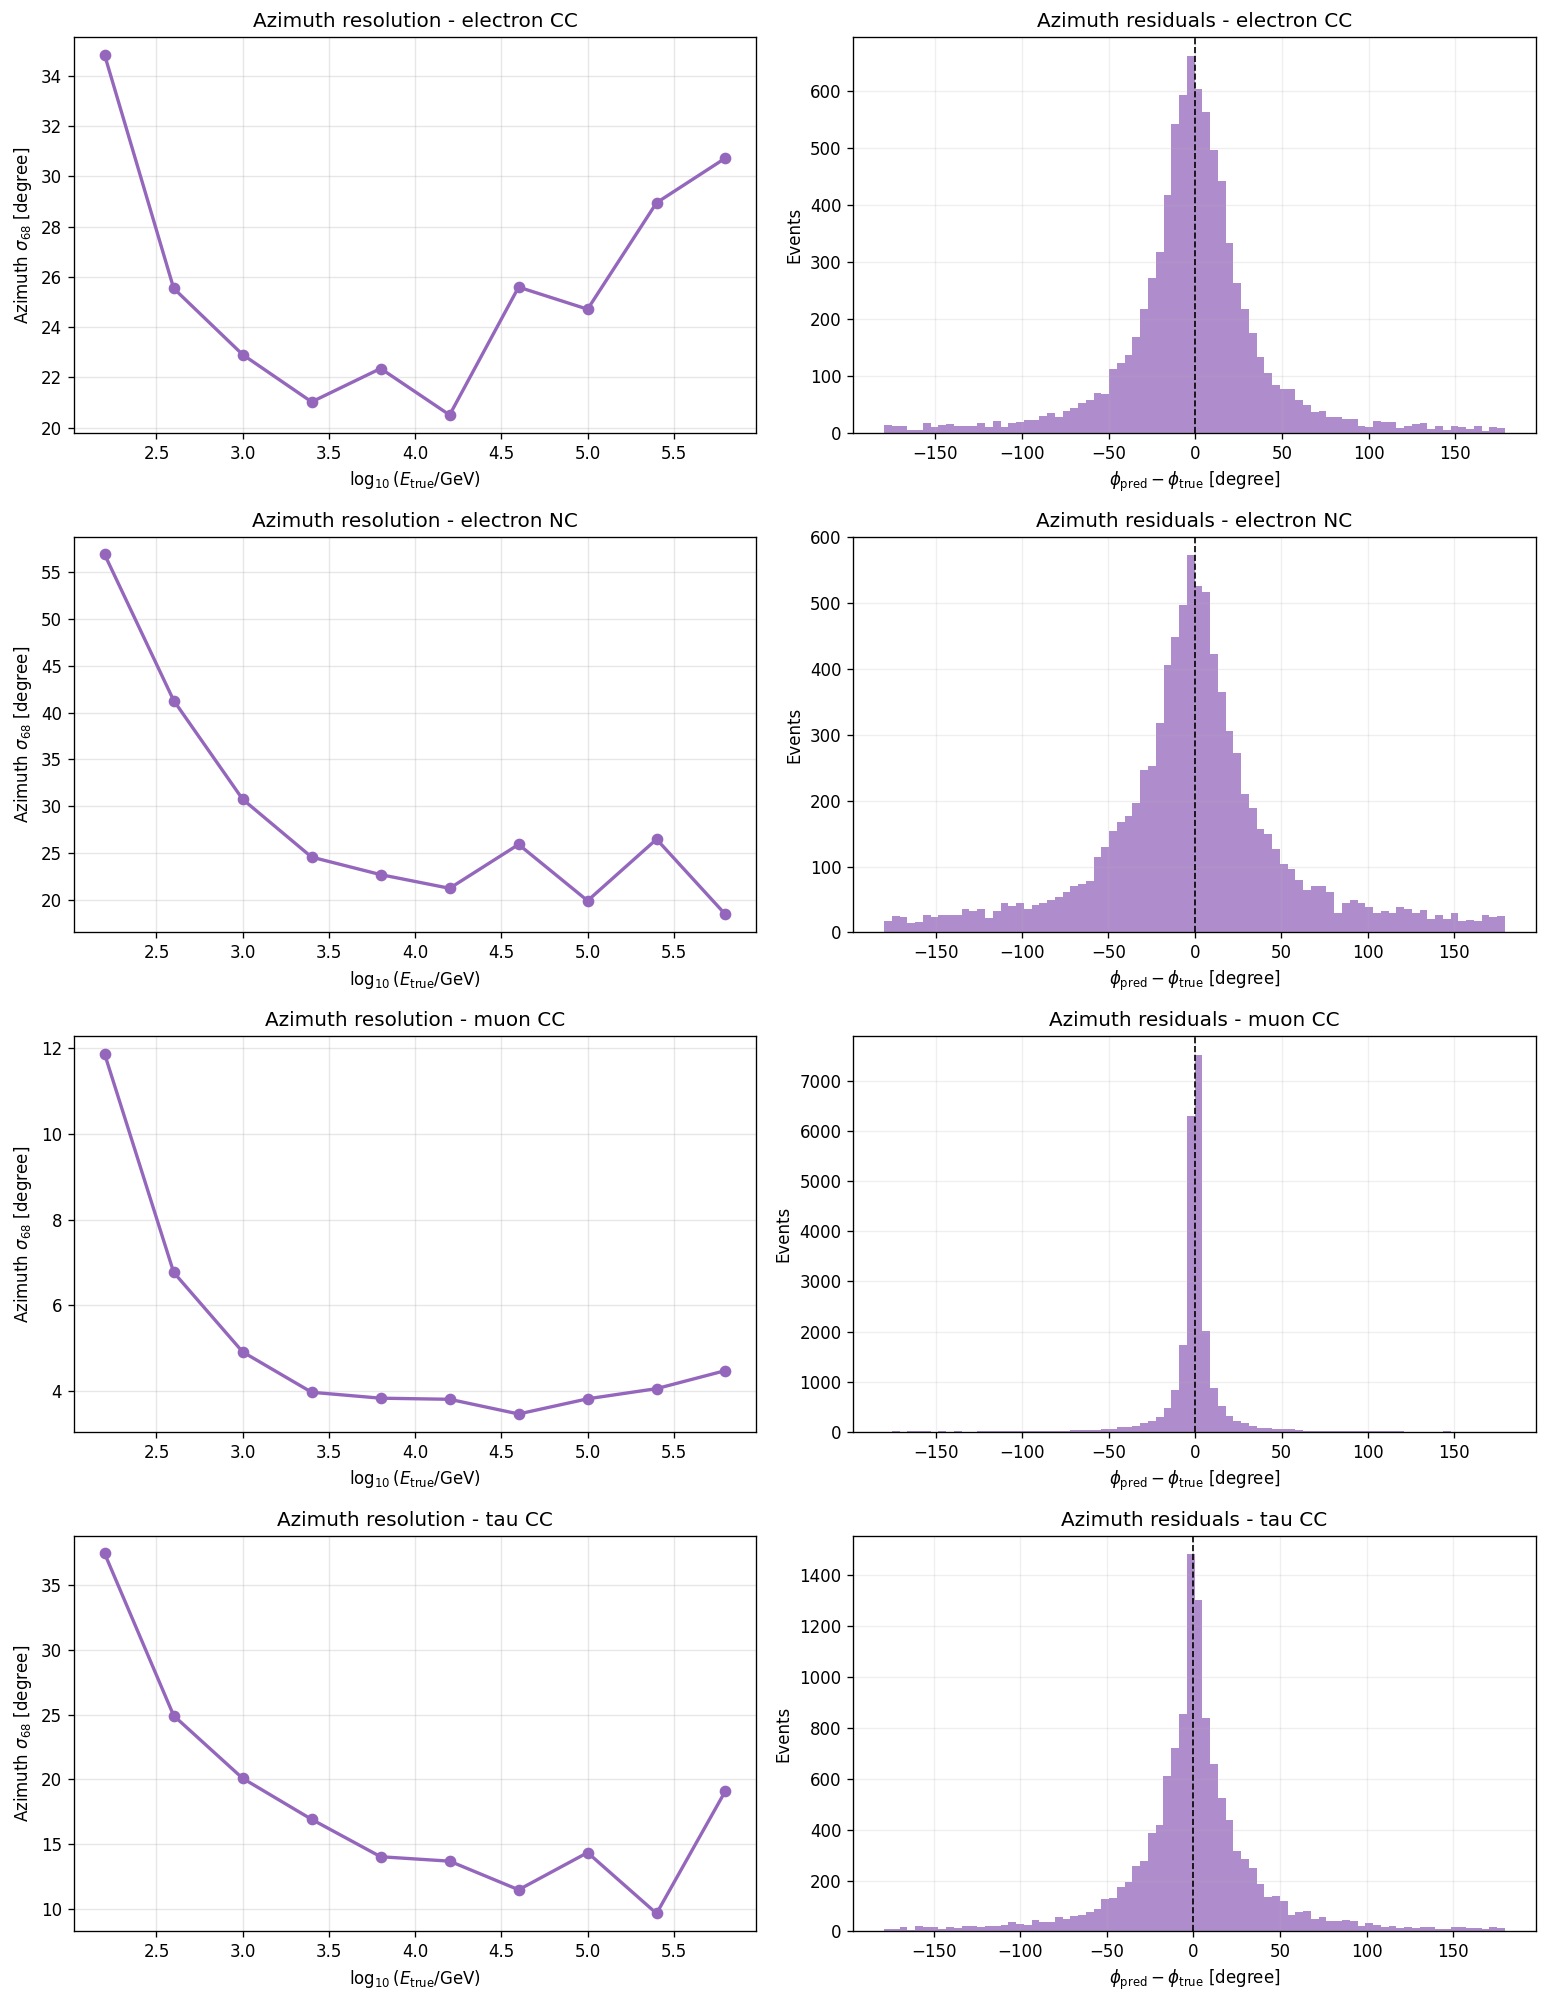

In [15]:
plot_resolution_and_residual_groups(
    azimuth_df,
    pid_interaction_grouped_frames(azimuth_df),
    residual_col="azimuth_residual_degree",
    y_label=r"Azimuth $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]",
    title_prefix="Azimuth",
    color="tab:purple",
)


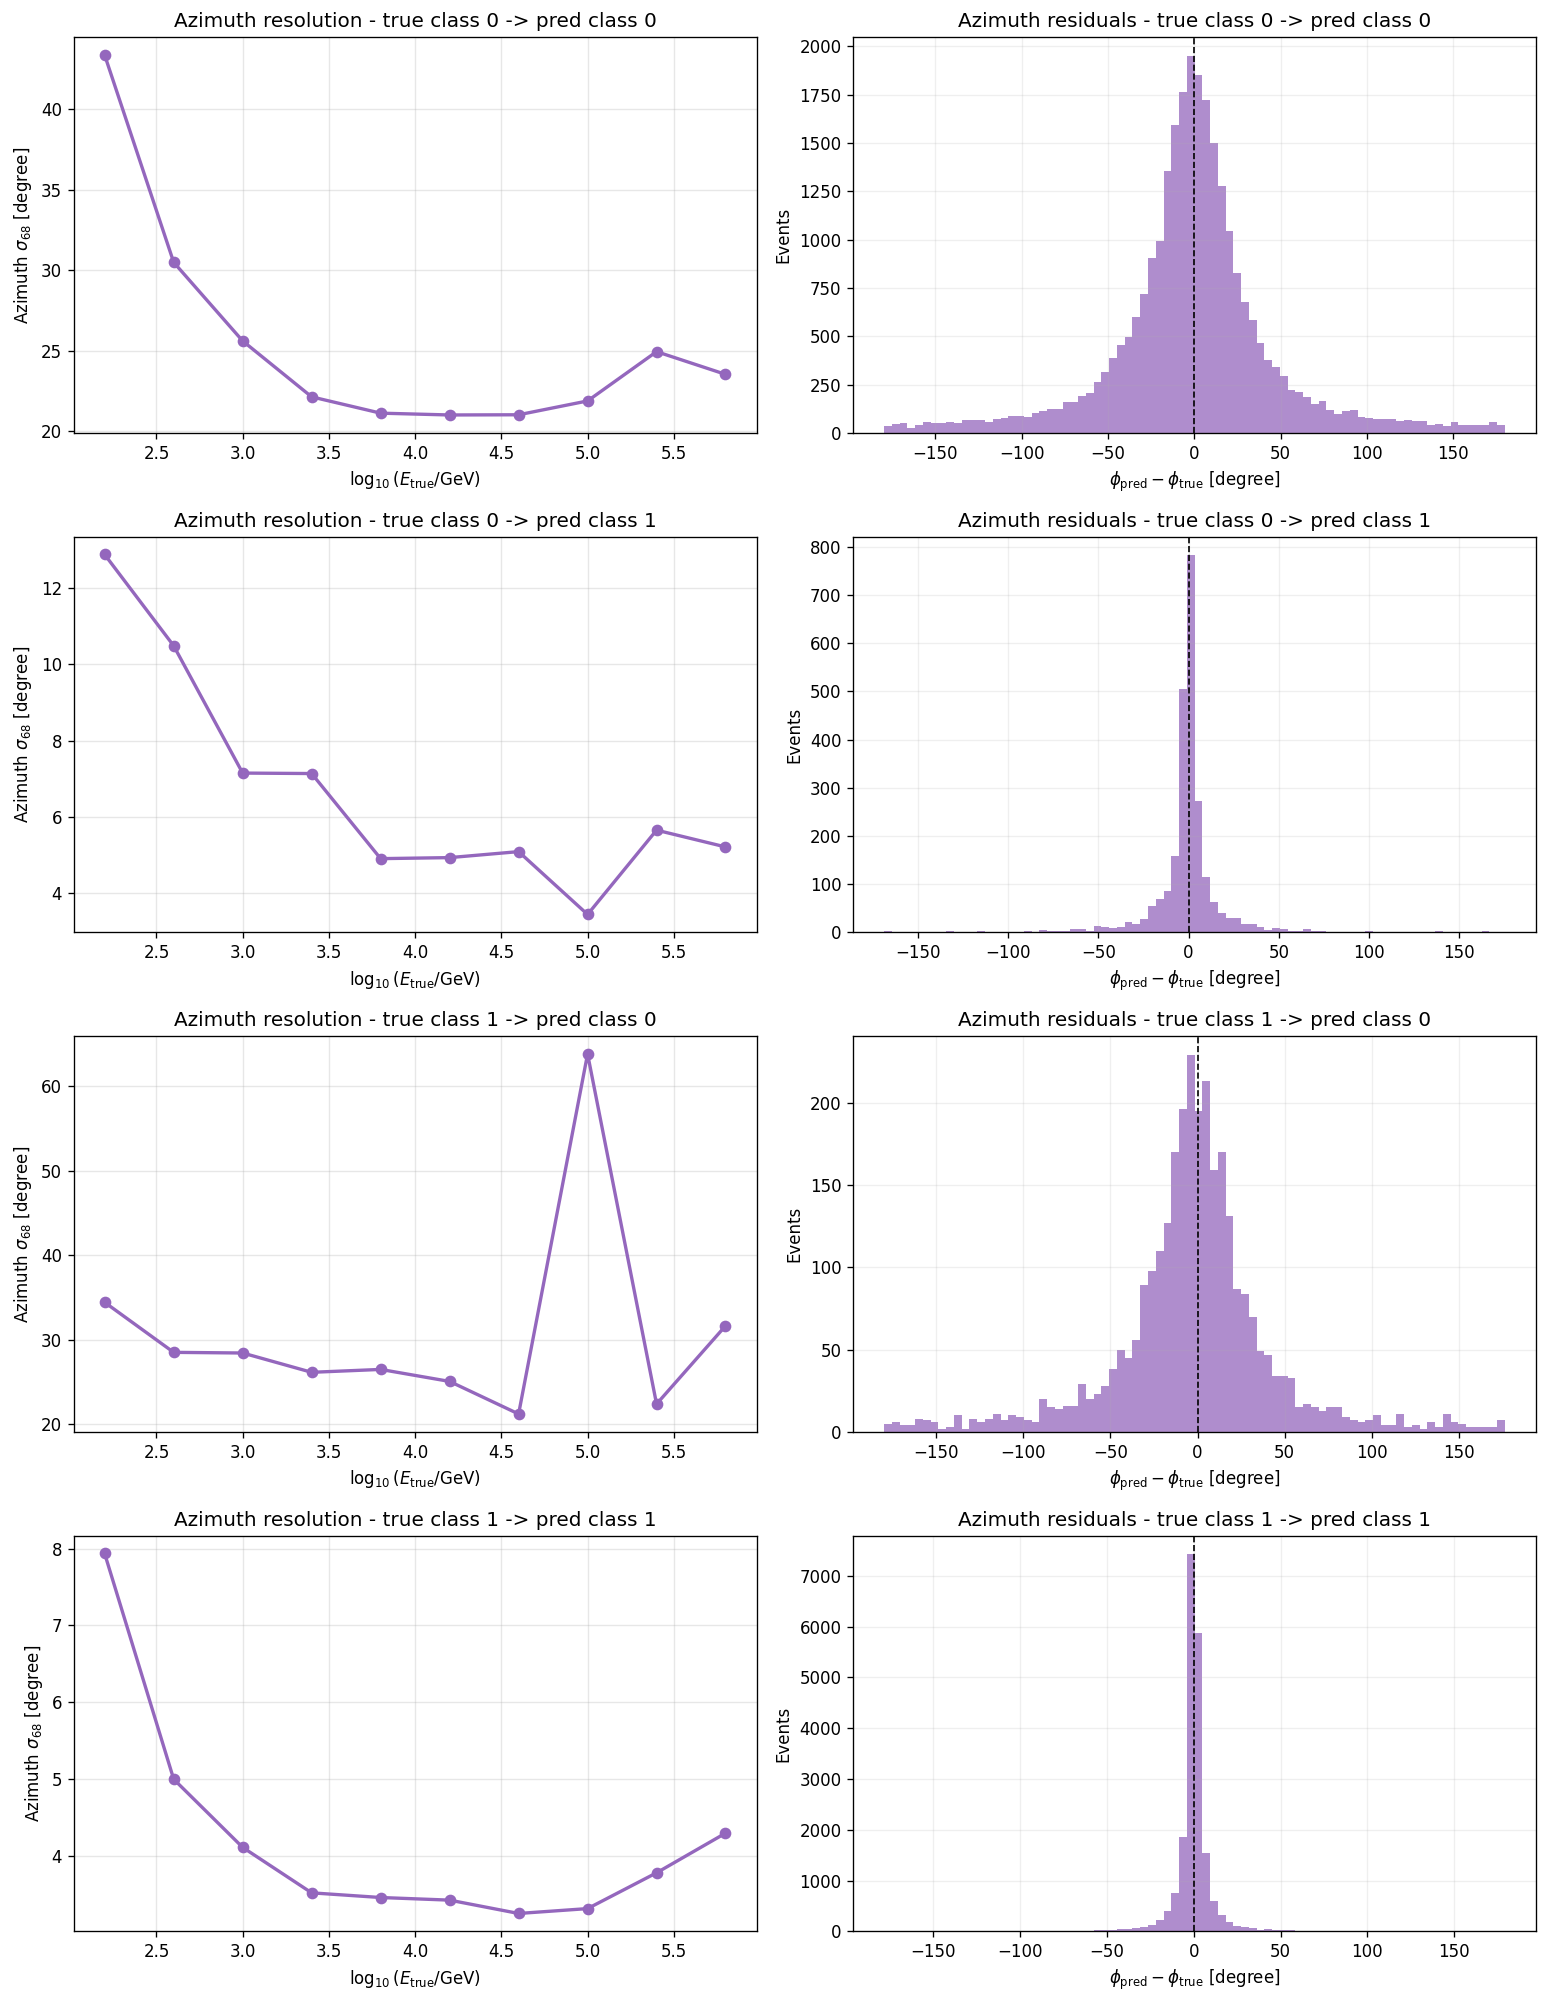

In [16]:
plot_resolution_and_residual_groups(
    azimuth_df,
    confusion_route_grouped_frames(azimuth_df),
    residual_col="azimuth_residual_degree",
    y_label=r"Azimuth $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]",
    title_prefix="Azimuth",
    color="tab:purple",
)


## Section 5 - Opening Angle


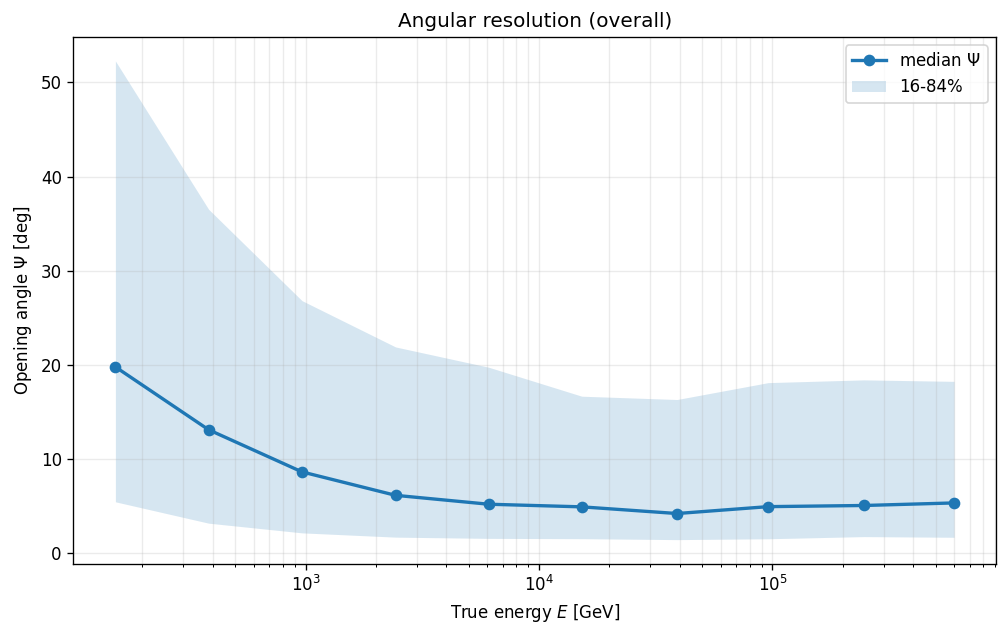

,bin_center_energy,count,median_psi,p16,p84
0,153.254380,18999,19.802836,5.481288,52.283972
1,384.335051,12192,13.130815,3.212721,36.535457
2,965.415865,7645,8.655868,2.183534,26.835684
3,2430.354639,5146,6.168007,1.729873,21.919671
4,6083.790715,3421,5.224446,1.598016,19.769842
5,15247.625300,2233,4.945457,1.566979,16.691305
6,39035.179969,1637,4.237223,1.465439,16.340717
7,95927.506872,1041,4.968354,1.556474,18.133238
8,246183.809896,694,5.089859,1.786789,18.425780
9,599595.482524,427,5.361848,1.714473,18.267666


In [17]:
def opening_angle_deg(theta_true, phi_true, theta_pred, phi_pred):
    cos_delta = (
        np.sin(theta_true) * np.sin(theta_pred) * np.cos(phi_true - phi_pred)
        + np.cos(theta_true) * np.cos(theta_pred)
    )
    return np.degrees(np.arccos(np.clip(cos_delta, -1.0, 1.0)))

zen_true = "zenith_true_zenith_radian" if "zenith_true_zenith_radian" in df.columns else "true_zenith_radian"
zen_pred = "zenith_pred_zenith_radian" if "zenith_pred_zenith_radian" in df.columns else "pred_zenith_radian"
azi_true = "azimuth_true_azimuth_radian" if "azimuth_true_azimuth_radian" in df.columns else "true_azimuth_radian"
azi_pred = "azimuth_pred_azimuth_radian" if "azimuth_pred_azimuth_radian" in df.columns else "pred_azimuth_radian"

opening_cols = ["true_energy", "true_log10_energy", true_class_col, analysis_group_col, pid_interaction_exact_col, zen_true, zen_pred, azi_true, azi_pred]
opening_df = df[opening_cols].dropna().copy()
opening_df["opening_angle_degree"] = opening_angle_deg(opening_df[zen_true], opening_df[azi_true], opening_df[zen_pred], opening_df[azi_pred])

opening_df["energy_bin"] = pd.cut(opening_df["true_log10_energy"], bins=bins, include_lowest=True)
opening_summary = (
    opening_df.groupby("energy_bin", observed=True)
    .agg(
        bin_center_log10=("true_log10_energy", "mean"),
        count=("opening_angle_degree", "size"),
        median_psi=("opening_angle_degree", "median"),
        p16=("opening_angle_degree", lambda x: np.percentile(x, 16)),
        p84=("opening_angle_degree", lambda x: np.percentile(x, 84)),
    )
    .reset_index(drop=True)
)
opening_summary = opening_summary[opening_summary["count"] > 0].copy()
opening_summary["bin_center_energy"] = 10 ** opening_summary["bin_center_log10"]

fig, ax = plt.subplots(figsize=(8.5, 5.4))
ax.plot(
    opening_summary["bin_center_energy"], opening_summary["median_psi"],
    marker="o", linewidth=2, color="tab:blue", label=r"median $\Psi$"
)
ax.fill_between(
    opening_summary["bin_center_energy"], opening_summary["p16"], opening_summary["p84"],
    color="tab:blue", alpha=0.18, linewidth=0, label="16-84%"
)
ax.set_xscale("log")
ax.set_xlabel(r"True energy $E$ [GeV]")
ax.set_ylabel(r"Opening angle $\Psi$ [deg]")
ax.set_title("Angular resolution (overall)")
ax.grid(True, alpha=0.25, which="both")
ax.legend()
fig.tight_layout()
plt.show()

opening_summary[["bin_center_energy", "count", "median_psi", "p16", "p84"]]


### Opening Angle by Flavor


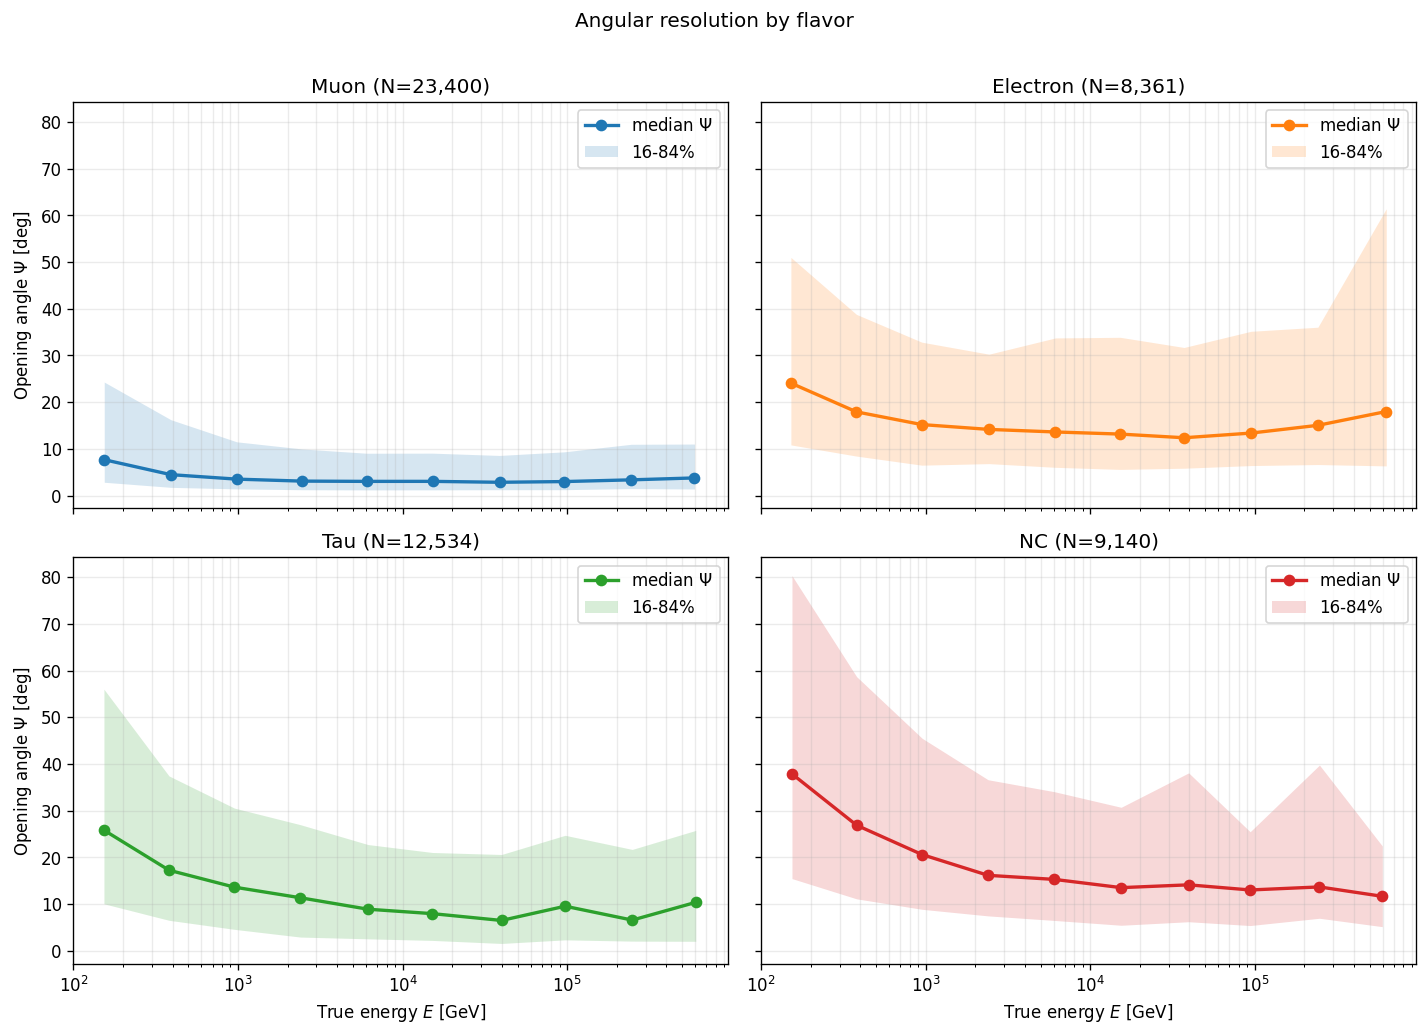

,flavor,bin_center_energy,count,median_psi,p16,p84
0,Muon,153.819418,6666,7.686624,2.854661,24.308759
1,Muon,390.852228,4672,4.484168,1.764027,16.247283
2,Muon,982.520656,3632,3.523728,1.433726,11.513774
3,Muon,2452.631203,2810,3.100244,1.254432,9.985447
4,Muon,6047.779713,1956,3.041550,1.219551,9.070474
5,Muon,15239.349612,1341,3.047259,1.230278,9.086654
6,Muon,38888.577108,1012,2.849548,1.258930,8.596320
7,Muon,96048.838309,623,3.003814,1.264370,9.368258
8,Muon,245528.500474,425,3.371792,1.499516,10.985958
9,Muon,594902.633913,263,3.782412,1.412289,11.038639


In [18]:
flavor_opening_df = df[["pid", "is_CC", "true_log10_energy", zen_true, zen_pred, azi_true, azi_pred]].dropna().copy()
flavor_opening_df["opening_angle_degree"] = opening_angle_deg(
    flavor_opening_df[zen_true], flavor_opening_df[azi_true],
    flavor_opening_df[zen_pred], flavor_opening_df[azi_pred]
)

pid_flavor = flavor_opening_df["pid"].abs().astype(int).map({12: "Electron", 14: "Muon", 16: "Tau"})
flavor_opening_df["flavor"] = np.where(
    flavor_opening_df["is_CC"].astype(int) == 0,
    "NC",
    pid_flavor,
)
flavor_opening_df = flavor_opening_df.dropna(subset=["flavor"])
flavor_opening_df["energy_bin"] = pd.cut(
    flavor_opening_df["true_log10_energy"], bins=bins, include_lowest=True
)

flavor_order = ["Muon", "Electron", "Tau", "NC"]
flavor_colors = {
    "Muon": "tab:blue",
    "Electron": "tab:orange",
    "Tau": "tab:green",
    "NC": "tab:red",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharex=True, sharey=True)
flavor_opening_summaries = {}

for ax, flavor in zip(axes.flat, flavor_order):
    flavor_df = flavor_opening_df[flavor_opening_df["flavor"] == flavor]
    summary = (
        flavor_df.groupby("energy_bin", observed=True)
        .agg(
            bin_center_log10=("true_log10_energy", "mean"),
            count=("opening_angle_degree", "size"),
            median_psi=("opening_angle_degree", "median"),
            p16=("opening_angle_degree", lambda x: np.percentile(x, 16)),
            p84=("opening_angle_degree", lambda x: np.percentile(x, 84)),
        )
        .reset_index(drop=True)
    )
    summary = summary[summary["count"] > 0].copy()
    summary["bin_center_energy"] = 10 ** summary["bin_center_log10"]
    flavor_opening_summaries[flavor] = summary

    color = flavor_colors[flavor]
    ax.plot(
        summary["bin_center_energy"], summary["median_psi"],
        marker="o", linewidth=2, color=color, label=r"median $\Psi$"
    )
    ax.fill_between(
        summary["bin_center_energy"], summary["p16"], summary["p84"],
        color=color, alpha=0.18, linewidth=0, label="16-84%"
    )
    ax.set_xscale("log")
    ax.set_title(f"{flavor} (N={len(flavor_df):,})")
    ax.grid(True, alpha=0.25, which="both")
    ax.legend()

for ax in axes[-1, :]:
    ax.set_xlabel(r"True energy $E$ [GeV]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Opening angle $\Psi$ [deg]")

fig.suptitle("Angular resolution by flavor", y=1.01)
fig.tight_layout()
plt.show()

pd.concat(
    [summary.assign(flavor=flavor) for flavor, summary in flavor_opening_summaries.items()],
    ignore_index=True,
)[["flavor", "bin_center_energy", "count", "median_psi", "p16", "p84"]]
